# Практическое задание 2

**Правила**

* Дедлайны см. в боте. После дедлайна работы не принимаются кроме случаев наличия уважительной причины.
* Выполненную работу нужно отправить телеграм-боту `@miptstats_ds24_bot`. Для начала работы с ботом каждый раз отправляйте `/start`. **Работы, присланные иным способом, не принимаются.**
* Дедлайны см. в боте. После дедлайна работы не принимаются кроме случаев наличия уважительной причины.
* Прислать нужно **ноутбук в формате `ipynb`**.
* Следите за размером файлов. **Бот не может принимать файлы весом более 20 Мб.** Если файл получается больше, заранее разделите его на несколько.
* Выполнять задание необходимо полностью самостоятельно. **При обнаружении списывания все участники списывания будут сдавать устный зачет.**
* Решения, размещенные на каких-либо интернет-ресурсах, не принимаются. Кроме того, публикация решения в открытом доступе может быть приравнена к предоставлении возможности списать.
* Для выполнения задания используйте этот ноутбук в качестве основы, ничего не удаляя из него. Можно добавлять необходимое количество ячеек.
* Комментарии к решению пишите в markdown-ячейках.
* Выполнение задания (ход решения, выводы и пр.) должно быть осуществлено на русском языке.
* Если код будет не понятен проверяющему, оценка может быть снижена.
* Никакой код из данного задания при проверке запускаться не будет. *Если код студента не выполнен, недописан и т.д., то он не оценивается.*
* В каждой задаче не забывайте делать **пояснения и выводы**.

**Особенности**
* Рассчитано на **три недели**.
* Состоит из **двух частей**. Обе части **не зависят друг от друга**.
* Задание большое, и сделать его в последний момент не получится. Поэтому сдача происходит *(почти)* **каждую неделю**.
* В вашем решении, которое вы сдаете в определенную неделю, в самом начале ноутбука должно быть указано, что было сделано за эту неделю. При этом за каждую сдачу должно быть сделано не менее 10% задания, иначе будет применен штраф.
* Что означает "*(почти) каждую неделю*": у вас **есть возможность пропустить одну неделю** сдачи из 3, но при условии, что в первую неделю нужно обязательно сдать хотя бы 10 процентов.
* В конце срока сдачи задания вам необходимо предоставить **полностью готовое решение** и отчет о том, что вы сделали **на каждой неделе**. Если не предоставить отчет, проверяющий может оценить объем по каждому дедлайну на свое усмотрение.
* Задание основано на открытых данных. К ним можно найти много ноутбуков с кодом. С ними будет полезно ознакомиться, поучиться чему-то новому, и что-то применить для своего решения. При этом **копирование бОльшей части кода без собственных комментариев и обновления кода будет штрафоваться**.

**Баллы**
* Часть 1 &mdash; 100 баллов
* Часть 2 &mdash; 100 баллов

**Рекомендации по выполнению**
1. Начинайте выполнение задания как можно раньше!
2. "Съешьте на завтрак слона". Задание разделено на несколько независимых частей. Начните выполнение с той части, которая вам кажется наиболее сложной и непонятной.
3. В Kaggle можно работать с ноутбуками и обучать модели. Иногда, возможно, будет удобнее, чем в Google Colab.
4. Для всех задач **рекомендуется** писать **аккуратный код в одном** `.py`-файле и обращаться к нему в jupyter-ноутбуке как-нибудь так: ```from my_super_module import gpt5```. Ноутбук используйте для запуска экспериментов, визуализаций, комментирования результатов и выводов.
5. Скорее всего в процессе выполнения задания вы будете логгировать промежуточные результаты, строить кривые обучения и т.д. Для этого мы рекомендуем присмотреться к инструментам [Weights & Biases](https://wandb.ai/), [Neptune](https://neptune.ai/) и т.п. Многие такие инструменты имеют интеграцию в `transformers`! В случае их использования не забудьте вставить получившиеся графики в ноутбук.
6. Используйте [Trainer](https://huggingface.co/docs/transformers/main_classes/trainer) из `transformers` для обучения моделей. Не стоит строить новый велосипед и снова писать классический цикл обучения, вы уже делали это раньше ;)
7. В процессе обучения не забывайте сохранять промежуточные результаты (чекпоинты моделей). Это удобно делать в google-drive, если пользуетесь Colab.
8. В NLP размер модели, а также количество и качество обучающих данных **имеет значение**. Не стоит брать совсем уж легкие архитектуры. Обучение в задачах скорее всего будет занимать не 5-10 минут, этого не стоит бояться.
9. Разумно подойдите к выбору гиперпараметров, исходя из вычислительных ресурсов. Обратите внимание на [пост](https://huggingface.co/docs/transformers/main/en/perf_train_gpu_one). На последнем занятии были рассмотрены техники, позволяющие обучать быстро даже большие модели на **одном** GPU.
___

In [2]:
import transformers
import evaluate

import json
import numpy as np
import pandas as pd
import datasets

import matplotlib.pyplot as plt
import seaborn as sns
sns.set(font_scale=1.2, palette="Set2")

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import DataLoader
from torch.utils.data import Dataset 
from sklearn.metrics import f1_score

from transformers import (
    AutoTokenizer,
    AutoModel,
    DataCollatorWithPadding,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    default_data_collator
)

from transformers import RobertaForSequenceClassification, RobertaTokenizer

from peft import (
    get_peft_config,
    get_peft_model,
    get_peft_model_state_dict,
    TaskType,
    LoraConfig
)

from tqdm.auto import tqdm
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, precision_score, recall_score

import wandb

2025-05-08 17:25:45.065860: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1746714345.198177     642 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1746714345.233386     642 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1746714345.523603     642 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1746714345.523633     642 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1746714345.523636     642 computation_placer.cc:177] computation placer alr

## Часть 1.

В этой части задания вы будете работать с данными уже завершившегося [соревнования](https://github.com/dialogue-evaluation/RuSentNE-evaluation) по анализу тональности к именованным сущностям в новостных текстах. Посмотрим на описание, которое представлено в репозитории.

Анализ тональности текста &mdash; извлечение выраженной в тексте эмоциональной оценки к некоторой сущности &mdash; одно из наиболее активно развивающихся направлений в автоматической обработке текстов.

Анализ тональности новостных текстов &mdash; важное направление в области анализа мнений, поскольку обнаружение, отслеживание трендов тональности в новостном потоке важно для построения разного рода аналитических систем, отслеживания имиджа в СМИ конкретных людей или компаний.

Тональность по отношению к сущности в новостном тексте может происходить по крайней мере из трех разных источников:
* мнения автора текста;
* цитируемого мнения, при этом сам носитель мнения может быть упомянут или не упомянут в тексте;
* имплицитного мнения, которое следует из каких-либо упомянутых действий или реакций, например, X уволил Y. Такая информация часто присутствует даже при внешне нейтральном изложении событий.

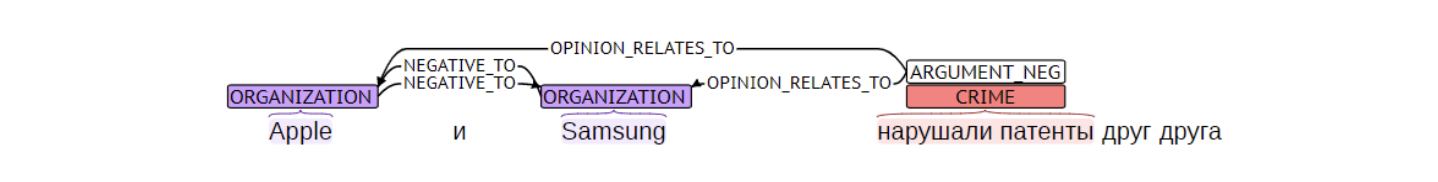

Вам предстоит решить задачу извлечения из новостных текстов тональности трёх классов (негативная, позитивная, нейтральная) по отношению к заранее размеченным сущностям типа `PERSON`, `ORGANIZATION`, `PROFESSION`, `COUNTRY`, `NATIONALITY` в рамках отдельного предложения.

Данные представлены в следующем формате:
* `sentence` &mdash; предложение;
* `entity` &mdash; объект анализа тональности;
* `entity_tag` &mdash; тип сущности, может быть `PERSON`, `ORGANIZATION`, `PROFESSION`, `COUNTRY`, `NATIONALITY`;
* `entity_pos_start_rel` и `entity_pos_end_rel` &mdash; индексы начала и конца упоминания сущности в предложении;
* `label` &mdash; метка тональности (0 &mdash; нейтрально, 1 &mdash; отрицательно, 1 &mdash; положительно).

Основной метрикой соревнования является $F_1-macro$ с **усреднением по двум классам**. Нейтральный класс исключается, т.к. важно выделить именно мнение. Таким образом, процедура оценки следующая:

1. Отдельно вычислить $F_1$ для каждого из классов.
2. Усреднить полученные значения $F_1$ для двух из трех классов.

Предлагается работать с `train` и `dev(val)` выборками. Для начала изучите бейзлайн, используемый авторами. Он содержит реализацию многих вспомогательных вещей, которыми мы на занятиях и в домашних заданиях пользовались через библиотеку `transformers`. Вы можете подчерпнуть некоторые моменты, но полностью копировать код бейзлайна **запрещается**.

Обучите свое собственное базовое решение и посчитайте качество на валидации. Подумайте, в каком формате лучше подавать на вход модели используемые данные? Вам может потребоваться добавить спец. тоцены в словарь, сделать это можно [так](https://github.com/huggingface/tokenizers/issues/247).

Попробуйте улучшить качество, проведя как минимум **два эксперимента**, в которых вы можете:
* Использовать другую базовую модель;
* Предварительно обучить базовую модель на задачу MLM на имеющимся корпусе текстов;
* Попробовать разные стратегии получения итогового представления и разные форматы входных данных. Например, можно сделать предсказание не из `[CLS]` токена, а из спец. токена (например `[PERSON]`) сущности **или** из вектора, полученного после пуллинга на токенах (например `['В', '##ася', 'П', '##уп', '##кин']`) описания сущности.
В этих случаях вход модели может выглядеть как-то так:
`[CLS] <текст новости> [PERSON] Вася Пупкин [SEP] <продолжение новости> [SEP]`
* Найти статьи, релевантные задаче, а также попробовать реализовать и применить описанные там методы. Можете изучить [статью](https://arxiv.org/pdf/2305.17679.pdf) от авторов соревнования. В этой работе описаны успешные решения победителей. В данном случае разрешается использовать код авторов, если таковой имеется. Свой выбор стоит кратко **обосновать**.

Быстро посмотрим на данные

In [2]:
train = pd.read_csv('train_data.csv', sep='\t')
val = pd.read_csv('validation_data_labeled.csv', sep='\t')
train.head()

,sentence,entity,entity_tag,entity_pos_start_rel,entity_pos_end_rel,label
0,"Джеймс «Бадди» Макгирт (James (Buddy) McGirt, ...",спортсмена,PROFESSION,86,96,0
1,«За всю нашу долгую карьеру нам довелось играт...,музыкантов,PROFESSION,258,268,0
2,"Ранее, 7 декабря, толпа болельщиков перекрыла ...",Егоре Свиридове,PERSON,175,190,0
3,"В субботу, 21 июля 2018 года, на арене СК «Оли...",россиянина,NATIONALITY,122,132,0
4,Представитель талибов Забиулла Муджахид в твит...,американских захватчика,PROFESSION,109,132,-1


TODO: гистограммы entiti_tag, label, длины текстов

### Бейзлайн

Метрики

In [3]:
def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)

    # 0 (нейтральный), 1 (позитивный), 2 (негативный)
    f1_per_class = f1_score(labels, predictions, labels=[0, 1, 2], average=None)
    f1_neutral, f1_pos, f1_neg = f1_per_class
    mask = labels != 0
    filtered_labels = labels[mask]
    filtered_preds = predictions[mask]

    f1_macro_1_2 = f1_score(filtered_labels, filtered_preds, labels=[1, 2], average="macro")

    return {
        "f1_neutral": f1_neutral,
        "f1_pos": f1_pos,
        "f1_neg": f1_neg,
        "f1_macro_1_2": f1_macro_1_2,
    }

Обернем все данные в структуру-датасет, которой будем передавать функцию-обработчика предложений. Данные заранее токенизируем. Паддинг будет динамический через `DataCollatorWithPadding` в `Trainer`.

In [4]:
class EntitySentimentDataset(Dataset):
    def __init__(self, csv_path, text_processor,
                 tokenizer=None, max_length=512):
        self.raw_data = pd.read_csv(csv_path, sep='\t')
        self.text_processor = text_processor
        self.tokenizer = tokenizer
        self.max_length = max_length
        self.processed_data = self._preprocess_data()
    
    def _preprocess_data(self):
        processed = []
        for _, row in tqdm(self.raw_data.iterrows(), leave=False):
            text = self.text_processor(row)
            entry = {'label': self._map_label(row['label'])}
            if self.tokenizer:
                # только обрезка
                tokens = self.tokenizer(
                    text,
                    truncation=True,
                    max_length=self.max_length,
                    return_attention_mask=True,
                    return_tensors='pt',
                )
                entry.update({
                    'input_ids': tokens.input_ids.squeeze(0),
                    'attention_mask': tokens.attention_mask.squeeze(0),
                })
            else:
                entry['text'] = text
            processed.append(entry)
        return processed
        
    def _map_label(self, label: int) -> int:
        """Приводит метки к формату 0,1,2"""
        return {0: 0, 1: 1, -1: 2}[label]
        
    def __len__(self):
        return len(self.processed_data)

    def __getitem__(self, idx):
        item = self.processed_data[idx]
        return {
            'input_ids':      item['input_ids'],
            'attention_mask': item['attention_mask'],
            'labels':         torch.tensor(item['label'], dtype=torch.long)
        }

Бейзлайн-обработчик: добавляем токены `entity_tag` и собственно оборачиваем объект `entity`. При этом надо обновить токенизатор, добавив в него спецсимволы

In [28]:
def no_text_process(row):
    return row['sentence']

def baseline_text_process(row):
    s = row['sentence']
    st, ed = row['entity_pos_start_rel'], row['entity_pos_end_rel']
    entity_tag = f"<{row['entity_tag']}>"
    return s[:st] + ' <ENT>' + s[st:ed] + '</ENT> ' + s[ed:] + ' Тип сущности ' + entity_tag

def baseline_update_tokenizator(tokenizator):
    entity_tags = ['<PERSON>', '<ORGANIZATION>', '<PROFESSION>', '<COUNTRY>', '<NATIONALITY>']
    entity_insert_tags = ['<ENT>', '</ENT>']
    tokenizator.add_special_tokens({"additional_special_tokens": entity_tags + entity_insert_tags})
    return

Попробуем Roberta

In [6]:
model_name = "DeepPavlov/rubert-base-cased"

tokenizer = transformers.AutoTokenizer.from_pretrained(model_name)
model = transformers.AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=3)

baseline_update_tokenizator(tokenizer)
model.resize_token_embeddings(len(tokenizer))

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at DeepPavlov/rubert-base-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
The new embeddings will be initialized from a multivariate normal distribution that has old embeddings' mean and covariance. As described in this article: https://nlp.stanford.edu/~johnhew/vocab-expansion.html. To disable this, use `mean_resizing=False`


Embedding(119554, 768, padding_idx=0)

Инициализация датасетов

In [7]:
train_dataset = EntitySentimentDataset("train_data.csv", baseline_text_process, tokenizer)
val_dataset = EntitySentimentDataset("validation_data_labeled.csv", baseline_text_process, tokenizer)

0it [00:00, ?it/s]

0it [00:00, ?it/s]

Параметры обучения. Не забудем коллокатор для динамического паддинга

In [8]:
training_args = TrainingArguments(
    output_dir="./checkpoints",
    num_train_epochs=10,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_dir="./logs",
    logging_steps=10,
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro_1_2",
    report_to="wandb",
    run_name="baseline-rubert",
    learning_rate=2e-5,
    weight_decay=0.01,

    push_to_hub=False,
    save_total_limit=1,
    #dataloader_num_workers=0,
)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

/tmp/ipykernel_5883/3418422280.py:24: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Запустим обучение

In [21]:
wandb.init(project="entity-sentiment-analysis", name="baseline-rubert")
trainer.train()
wandb.finish()

Epoch,Training Loss,Validation Loss,F1 Neutral,F1 Pos,F1 Neg,F1 Macro 1 2
1,0.474200,0.519360,0.873173,0.464978,0.571429,0.597764
2,0.512200,0.487205,0.879862,0.553360,0.655926,0.718893
3,0.228900,0.578638,0.881576,0.572988,0.676533,0.749472
4,0.066600,0.791188,0.895197,0.583450,0.676023,0.722432
5,0.033600,1.019436,0.895357,0.583799,0.648715,0.700814
6,0.017000,1.170465,0.889894,0.607692,0.680258,0.768054
7,0.011600,1.302900,0.890500,0.600791,0.672395,0.755203
8,0.011000,1.353598,0.889277,0.596583,0.672470,0.752449
9,0.003300,1.343520,0.893544,0.604082,0.680045,0.749090
10,0.000200,1.353198,0.893323,0.604716,0.674725,0.746132


eval/f1_macro_1_2,▁▆▇▆▅█▇▇▇▇
eval/f1_neg,▁▆██▆█▇▇██
eval/f1_neutral,▁▃▄██▆▆▆▇▇
eval/f1_pos,▁▅▆▇▇██▇██
eval/loss,▁▁▂▃▅▇████
eval/runtime,▁▁▇▂▂█▁▂▅▁
eval/samples_per_second,▇█▁▆▇▁█▇▃█
eval/steps_per_second,▇█▁▆▇▁█▇▃█
train/epoch,▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▄▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▇▇██
train/global_step,▁▁▁▁▁▁▂▂▂▂▂▃▃▃▃▃▃▃▄▄▄▅▅▅▅▅▅▆▆▆▆▇▇▇▇▇▇███
train/grad_norm,▂▃▃▄▄▃▁▄▅▂▄▂▁▁▅▅▅█▁▁▁▁▄▁▁▁▁▁▁▁▅▁▁▁▁▁▁▁▁▁


### Эксперимент 1.

Попробуем модель обучать на multitask: параллельно определять есть ли оценка вообще, и классификацию тональности. Идея: можно избавиться от дисбаланса классов

Модифируем модель и трейнер

In [79]:
class RuBERTMultiTask(nn.Module):
    def __init__(self, model_name="DeepPavlov/rubert-base-cased"):
        super().__init__()
        self.bert = AutoModel.from_pretrained(model_name)
        self.dropout = nn.Dropout(0.1)
        self.hidden_size = self.bert.config.hidden_size
        # Есть ли оценка
        self.classifier1 = nn.Linear(self.hidden_size, 2)
        # Какая оценка
        self.classifier2 = nn.Linear(self.hidden_size, 3)

    def forward(self, input_ids, attention_mask, labels_task1=None, labels_task2=None):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        cls_output = self.dropout(outputs.last_hidden_state[:, 0, :])  # [CLS]

        logits1 = self.classifier1(cls_output)
        logits2 = self.classifier2(cls_output)

        loss = None
        if labels_task1 is not None and labels_task2 is not None:
            loss_fn = nn.CrossEntropyLoss()
            loss1 = loss_fn(logits1, labels_task1)
            loss2 = loss_fn(logits2, labels_task2)
            loss = 0.5 * loss1 + 0.5 * loss2 

        return {
            "loss": loss,
            "logits1": logits1,
            "logits2": logits2,
        }

Модифицируем датасет

In [80]:
class MultitaskEntitySentimentDataset(Dataset):
    def __init__(self, csv_path, text_processor,
                 tokenizer=None, max_length=512):
        self.raw_data = pd.read_csv(csv_path, sep='\t')
        self.text_processor = text_processor
        self.tokenizer = tokenizer
        self.max_length = max_length
        self.processed_data = self._preprocess_data()
    
    def _preprocess_data(self):
        processed = []
        for _, row in tqdm(self.raw_data.iterrows(), leave=False):
            text = self.text_processor(row)
            entry = {
                    'label_task1': self._map_label_task1(row['label']),
                    'label_task2': self._map_label_task2(row['label']),
            }
            if self.tokenizer:
                # только обрезка
                tokens = self.tokenizer(
                    text,
                    truncation=True,
                    max_length=self.max_length,
                    return_attention_mask=True,
                    return_tensors='pt',
                )
                entry.update({
                    'input_ids': tokens.input_ids.squeeze(0),
                    'attention_mask': tokens.attention_mask.squeeze(0),
                })
            else:
                entry['text'] = text
            processed.append(entry)
        return processed
        
    def _map_label_task1(self, label):
        return 0 if label == 0 else 1

    def _map_label_task2(self, label):
        return {0: 0, -1: 1, 1: 2}[label]
        
    def __len__(self):
        return len(self.processed_data)

    def __getitem__(self, idx):
        item = self.processed_data[idx]
        return {
            'input_ids':      item['input_ids'],
            'attention_mask': item['attention_mask'],
            'labels_task1':   torch.tensor(item['label_task1'], dtype=torch.long),
            'labels_task2':   torch.tensor(item['label_task2'], dtype=torch.long),
        }

Делать предсказания теперь будем по обоим оценкам. Сначала определяем есть ли оценка вообще, затем, если есть, выбираем ее тональность.

In [102]:
def compute_metrics_exp1(eval_pred):
    logits_both, labels_both = eval_pred
    logits_task1, logits_task2 = logits_both
    labels_task1, labels = labels_both

    logits_task1 = np.array(logits_task1[:, :2])
    logits_task2 = np.array(logits_task2[:, :3])

    predictions_task1 = np.argmax(logits_task1, axis=1)
    logits_non_neutral = logits_task2[predictions_task1 == 1, 1:3] 

    predictions = np.zeros_like(predictions_task1) 
    predictions[predictions_task1 == 1] = np.argmax(logits_non_neutral, axis=1) + 1

    # Метрика для задачи классификации наличия оценки
    f1_task1 = f1_score(labels_task1, predictions_task1, average="binary")

    # Далее как обычно
    f1_per_class = f1_score(labels, predictions, labels=[0, 1, 2], average=None)
    f1_neutral, f1_pos, f1_neg = f1_per_class
    mask = labels != 0
    filtered_labels = labels[mask]
    filtered_preds = predictions[mask]

    f1_macro_1_2 = f1_score(filtered_labels, filtered_preds, labels=[1, 2], average="macro")

    return {
        "f1_is_not_neutral": f1_task1,
        "f1_neutral": f1_neutral,
        "f1_pos": f1_pos,
        "f1_neg": f1_neg,
        "f1_macro_1_2": f1_macro_1_2,
    }


Определим модель

In [93]:
tokenizer_exp1 = AutoTokenizer.from_pretrained(model_name)
baseline_update_tokenizator(tokenizer_exp1)

model_exp1 = RuBERTMultiTask(model_name)
model_exp1.bert.resize_token_embeddings(len(tokenizer_exp1)) 

Some weights of the model checkpoint at DeepPavlov/rubert-base-cased were not used when initializing BertModel: ['cls.predictions.bias', 'cls.predictions.decoder.bias', 'cls.predictions.decoder.weight', 'cls.predictions.transform.LayerNorm.bias', 'cls.predictions.transform.LayerNorm.weight', 'cls.predictions.transform.dense.bias', 'cls.predictions.transform.dense.weight', 'cls.seq_relationship.bias', 'cls.seq_relationship.weight']
- This IS expected if you are initializing BertModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


Embedding(119547, 768, padding_idx=0)

Инициализируем датасеты

In [89]:
train_dataset_exp1 = MultitaskEntitySentimentDataset("train_data.csv",
                                                baseline_text_process, tokenizer_exp1)
val_dataset_exp1 = MultitaskEntitySentimentDataset("validation_data_labeled.csv", baseline_text_process,
                                              tokenizer_exp1)

0it [00:00, ?it/s]

0it [00:00, ?it/s]

Параметры обучения. Не забудем коллокатор для динамического паддинга

In [103]:
training_args_exp1 = TrainingArguments(
    output_dir="./checkpoints_exp1",
    num_train_epochs=10,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_dir="./logs",
    logging_steps=10,
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro_1_2",
    report_to="wandb",
    run_name="rubert-multitask",
    learning_rate=2e-5,
    weight_decay=0.01,

    push_to_hub=False,
    save_total_limit=1,
    #dataloader_num_workers=0,
)

data_collator_exp1 = DataCollatorWithPadding(tokenizer=tokenizer_exp1)

trainer_exp1 = Trainer(
    model=model_exp1,
    args=training_args_exp1,
    train_dataset=train_dataset_exp1,
    eval_dataset=val_dataset_exp1,
    tokenizer=tokenizer_exp1,
    data_collator=data_collator_exp1,
    compute_metrics=compute_metrics_exp1,
)

/tmp/ipykernel_2790/1753622064.py:24: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer_exp1 = Trainer(


Запустим обучение

In [104]:
wandb.init(project="entity-sentiment-analysis", name="rubert-multitask-exp1")
trainer_exp1.train()
wandb.finish()

train/epoch,▁▁▁▂▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇██
train/global_step,▁▁▁▂▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇██
train/grad_norm,▂▂▃▂▃▂▃▆▇▁▁▄▂█▁▄▃▂▄▁▃▁▅▂▁▁▁▁▁▁▂▁▆▁▄▂▁▄▅▁
train/learning_rate,███▇▇▇▇▇▇▆▆▆▆▆▆▅▅▅▅▅▅▄▄▄▄▄▃▃▃▃▃▃▂▂▂▂▂▂▁▁
train/loss,▄▇▄▃▂▆▃▅▂▂▃▅▄▁█▆▅▃▂▃▂▂▄▁▃▂▃▁▆▂▄▂▂▂▂▂▂▃▂▄
train/epoch,0.98795
train/global_step,410
train/grad_norm,0.42999
train/learning_rate,2e-05
train/loss,0.1358


Epoch,Training Loss,Validation Loss,F1 Is Not Neutral,F1 Neutral,F1 Pos,F1 Neg,F1 Macro 1 2
1,0.030400,1.106882,0.689918,0.881109,0.536313,0.536585,0.628294
2,0.274400,0.592568,0.729358,0.880385,0.654797,0.572988,0.744989
3,0.279100,0.957074,0.694480,0.884802,0.616352,0.566186,0.687503
4,0.056500,1.046148,0.720102,0.893152,0.668103,0.549689,0.700091
5,0.018900,1.175153,0.725664,0.894352,0.668810,0.563945,0.709280
6,0.047600,1.252429,0.737030,0.890107,0.669447,0.579387,0.738477
7,0.007700,1.320519,0.735187,0.891477,0.663158,0.576705,0.728535
8,0.000100,1.345926,0.728192,0.895326,0.664303,0.584239,0.718221
9,0.000200,1.369114,0.741682,0.894228,0.673181,0.587432,0.737763
10,0.000100,1.379708,0.736397,0.891972,0.673098,0.585298,0.738893


eval/f1_is_not_neutral,▁▆▂▅▆▇▇▆█▇
eval/f1_macro_1_2,▁█▅▅▆█▇▆██
eval/f1_neg,▁▆▅▃▅▇▇███
eval/f1_neutral,▁▁▃▇█▆▆█▇▆
eval/f1_pos,▁▇▅███▇███
eval/loss,▆▁▄▅▆▇▇███
eval/runtime,▂▁▁▂▂▄▆█▁▁
eval/samples_per_second,▇▇█▆▆▅▃▁▇█
eval/steps_per_second,▇▇█▆▆▅▃▁▇█
train/epoch,▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▄▄▅▅▅▅▅▅▅▆▆▆▇▇▇▇▇██
train/global_step,▁▁▁▁▁▂▂▂▂▂▃▃▃▃▃▃▄▄▅▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇▇▇██


Метрика F1_pos - чуть лучше, F1_neg - чуть хуже, F1_macro - чуть хуже. Стоить попробовать другую стратегию. Если первый классификатор говорит, что оценка есть, но по второму классификатору тональность отдает большее предпочтение нейтральному классу, то выберем наиболее вероятный клас из не-нейтральных.

In [110]:
def compute_metrics_exp1_alternative_strategy(eval_pred):
    logits_both, labels_both = eval_pred
    logits_task1, logits_task2 = logits_both
    labels_task1, labels = labels_both

    logits_task1 = np.array(logits_task1[:, :2])
    logits_task2 = np.array(logits_task2[:, :3])

    predictions_task1 = np.argmax(logits_task1, axis=1)
    logits_non_neutral = logits_task2[predictions_task1 == 1, 1:3] 

    predictions = np.argmax(logits_task2, axis=1)
    predictions[predictions_task1 != 0] = np.argmax(logits_non_neutral, axis=1) + 1
    
    # Метрика для задачи классификации наличия оценки
    f1_task1 = f1_score(labels_task1, predictions_task1, average="binary")

    # Далее как обычно
    f1_per_class = f1_score(labels, predictions, labels=[0, 1, 2], average=None)
    f1_neutral, f1_pos, f1_neg = f1_per_class
    mask = labels != 0
    filtered_labels = labels[mask]
    filtered_preds = predictions[mask]

    f1_macro_1_2 = f1_score(filtered_labels, filtered_preds, labels=[1, 2], average="macro")

    return {
        "f1_is_not_neutral": f1_task1,
        "f1_neutral": f1_neutral,
        "f1_pos": f1_pos,
        "f1_neg": f1_neg,
        "f1_macro_1_2": f1_macro_1_2,
    }


Инициализация модели

In [111]:
model_exp1_alternative = RuBERTMultiTask(model_name)
model_exp1_alternative.bert.resize_token_embeddings(len(tokenizer_exp1)) 

Some weights of the model checkpoint at DeepPavlov/rubert-base-cased were not used when initializing BertModel: ['cls.predictions.bias', 'cls.predictions.decoder.bias', 'cls.predictions.decoder.weight', 'cls.predictions.transform.LayerNorm.bias', 'cls.predictions.transform.LayerNorm.weight', 'cls.predictions.transform.dense.bias', 'cls.predictions.transform.dense.weight', 'cls.seq_relationship.bias', 'cls.seq_relationship.weight']
- This IS expected if you are initializing BertModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


Embedding(119547, 768, padding_idx=0)

Запуск обучения

In [112]:
trainer_exp1_alt = Trainer(
    model=model_exp1_alternative,
    args=training_args_exp1,
    train_dataset=train_dataset_exp1,
    eval_dataset=val_dataset_exp1,
    tokenizer=tokenizer_exp1,
    data_collator=data_collator_exp1,
    compute_metrics=compute_metrics_exp1_alternative_strategy,
)

wandb.init(project="entity-sentiment-analysis", name="rubert-multitask-exp1-alternative-strategy")
trainer_exp1_alt.train()
wandb.finish()

/tmp/ipykernel_2790/1117354651.py:1: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer_exp1_alt = Trainer(


train/epoch,▁▁▁▂▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇██
train/global_step,▁▁▁▂▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇██
train/grad_norm,▂▂▃▁▁▃▂▃▃▃▃▃▃▂▃▄▃▂▂▃▄█▄▄▃▅▃▂▃▄▅▃▇▃▄▄▃▅▇▂
train/learning_rate,███▇▇▇▇▇▇▆▆▆▆▆▆▅▅▅▅▅▅▄▄▄▄▄▃▃▃▃▃▃▂▂▂▂▂▂▁▁
train/loss,▇▇▆▆▅▅█▄▅▅▅▇▃▃▅▄▃▄▃▃▅▄▅▂▄▃▄▃▃▁▄▄▄▁▁▃▅▃▄▁
train/epoch,0.98795
train/global_step,410
train/grad_norm,3.79208
train/learning_rate,2e-05
train/loss,0.4229


Epoch,Training Loss,Validation Loss,F1 Is Not Neutral,F1 Neutral,F1 Pos,F1 Neg,F1 Macro 1 2
1,0.416800,0.442345,0.661519,0.872372,0.572781,0.445033,0.607546
2,0.483300,0.406600,0.706182,0.887266,0.646600,0.539359,0.690183
3,0.258200,0.496263,0.712244,0.886598,0.662921,0.567493,0.722620
4,0.132400,0.723095,0.718593,0.890029,0.682154,0.559140,0.721542
5,0.077800,0.933611,0.680139,0.892286,0.634961,0.548485,0.660006
6,0.003900,1.043956,0.712644,0.898620,0.661037,0.540212,0.671566
7,0.003100,1.080889,0.737624,0.895009,0.674183,0.578804,0.727809
8,0.000200,1.151498,0.730745,0.896401,0.665094,0.586301,0.718001
9,0.000200,1.183860,0.731061,0.896854,0.666667,0.583099,0.718323
10,0.000200,1.195273,0.737888,0.896907,0.671946,0.595628,0.733214


eval/f1_is_not_neutral,▁▅▆▆▃▆█▇▇█
eval/f1_macro_1_2,▁▆▇▇▄▅█▇▇█
eval/f1_neg,▁▅▇▆▆▅▇█▇█
eval/f1_neutral,▁▅▅▆▆█▇▇██
eval/f1_pos,▁▆▇█▅▇▇▇▇▇
eval/loss,▁▁▂▄▆▇▇███
eval/runtime,▁▂▁█▂▂▂▁▁▁
eval/samples_per_second,█▆█▁▇▇▆▇██
eval/steps_per_second,█▆█▁▇▇▆▇██
train/epoch,▁▁▁▁▂▂▂▂▂▂▂▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▅▆▆▆▆▆▆▆▆▇▇▇██
train/global_step,▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇████


Вывод по **эксперименту 1** - потенциально мы можем улучшить предсказания. Имеет смысл попробовать немного другой способ - затюнить пороги классификации. Стоит получить рост f1_pos без размена на f1_neg. При этом модель всегда переобучается и получает очень маленький лосс на трейне, поэтому потенциальный выигрыш не такой большой. 

### Эксперимент 2

Попробуем сделать предсказания по спец токену сущности `<ENT>`. Идея: в нем хранится больше контекста о субъекте оценки

In [14]:
class SingleTask(nn.Module):
    def __init__(self, ent_token_id, model_name="DeepPavlov/rubert-base-cased", num_labels=3,
                 loss_weights=torch.tensor([0.1, 1.0, 1.0])):
        super().__init__()
        self.bert = AutoModel.from_pretrained(model_name)
        self.dropout = nn.Dropout(0.1)
        self.hidden_size = self.bert.config.hidden_size
        
        self.ent_token_id = ent_token_id
        self.num_labels = num_labels
        self.loss_weights = loss_weights
        
        self.classifier = nn.Linear(self.hidden_size, self.num_labels)

    def forward(self, input_ids, attention_mask, labels=None):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        
        mask = (input_ids == self.ent_token_id)
        has_token = mask.any(dim=1)
        if not torch.all(has_token):
            missing_samples = torch.where(~has_token)[0].tolist()
            raise ValueError(f"Token {self.ent_token_id} не найден в samples: {missing_samples}")
        ent_token_pos = mask.long().argmax(dim=1)
        
        batch_indices = torch.arange(input_ids.size(0), device=input_ids.device)
        token_output = outputs.last_hidden_state[batch_indices, ent_token_pos, :]
        
        token_output = self.dropout(token_output)
        logits = self.classifier(token_output)

        loss = None
        if labels is not None:
            loss_fn = nn.CrossEntropyLoss(weight=self.loss_weights)
            loss = loss_fn(logits, labels)
        
        return {
            "loss": loss,
            "logits": logits,
        }

Инициализация модели

In [17]:
tokenizer_exp2 = transformers.AutoTokenizer.from_pretrained(model_name)
baseline_update_tokenizator(tokenizer_exp2)

ent_token_id = tokenizer_exp2.convert_tokens_to_ids('<ENT>')
model_exp2 = SingleTask(ent_token_id, model_name, num_labels=3)
model_exp2.bert.resize_token_embeddings(len(tokenizer_exp2))

Some weights of the model checkpoint at DeepPavlov/rubert-base-cased were not used when initializing BertModel: ['cls.predictions.bias', 'cls.predictions.decoder.bias', 'cls.predictions.decoder.weight', 'cls.predictions.transform.LayerNorm.bias', 'cls.predictions.transform.LayerNorm.weight', 'cls.predictions.transform.dense.bias', 'cls.predictions.transform.dense.weight', 'cls.seq_relationship.bias', 'cls.seq_relationship.weight']
- This IS expected if you are initializing BertModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
The new embeddings will be initialized from a multivariate normal distribution that has old embeddings' mean and

Embedding(119554, 768, padding_idx=0)

Функции для обучения

In [18]:
training_args_exp2 = TrainingArguments(
    output_dir="./checkpoints",
    num_train_epochs=10,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_dir="./logs",
    logging_steps=10,
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro_1_2",
    report_to="wandb",
    run_name="rubert-exp2-ent-token",
    learning_rate=2e-5,
    weight_decay=0.01,

    push_to_hub=False,
    save_total_limit=1,
    #dataloader_num_workers=0,
)

data_collator_exp2 = DataCollatorWithPadding(tokenizer=tokenizer_exp2)

trainer_exp2 = Trainer(
    model=model_exp2,
    args=training_args_exp2,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    tokenizer=tokenizer_exp2,
    data_collator=data_collator_exp2,
    compute_metrics=compute_metrics,
)

/tmp/ipykernel_6748/1540363540.py:24: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer_exp2 = Trainer(


Запуск обучения

In [43]:
wandb.init(project="entity-sentiment-analysis", name="rubert-exp2-ent-token")
trainer_exp2.train()
wandb.finish()

Epoch,Training Loss,Validation Loss,F1 Neutral,F1 Pos,F1 Neg,F1 Macro 1 2
1,0.445000,0.505578,0.878885,0.476780,0.517964,0.548370
2,0.458500,0.463945,0.888134,0.558692,0.656250,0.703853
3,0.143300,0.688041,0.880059,0.548128,0.647399,0.708654
4,0.088700,1.014681,0.890988,0.576577,0.636161,0.697775
5,0.003200,1.203080,0.898961,0.555891,0.638889,0.661943
6,0.002100,1.391101,0.889993,0.582763,0.667382,0.738109
7,0.001300,1.406636,0.893137,0.589849,0.665153,0.728980
8,0.005500,1.461182,0.894827,0.604520,0.660022,0.732061
9,0.000100,1.471866,0.895033,0.600536,0.660443,0.729265
10,0.000100,1.474997,0.897020,0.600000,0.647687,0.712729


eval/f1_macro_1_2,▁▇▇▇▅████▇
eval/f1_neg,▁▇▇▇▇████▇
eval/f1_neutral,▁▄▁▅█▅▆▇▇▇
eval/f1_pos,▁▅▅▆▅▇▇███
eval/loss,▁▁▃▅▆▇████
eval/runtime,▁▁▂▁█▁▁▂▂▁
eval/samples_per_second,▇█▇█▁▇█▆▇█
eval/steps_per_second,▇█▇█▁▇█▆▇█
train/epoch,▁▁▁▁▁▂▂▃▃▃▃▃▃▃▃▄▄▄▅▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇▇███
train/global_step,▁▁▁▁▁▁▁▁▂▂▂▂▂▂▂▃▃▄▄▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇████
train/grad_norm,▂▃▂▂▂▃▃▃▃▂▅▄▃▁█▁▃▁▁▂▁▁▁▁▁▄▁▁▁▁▁▁▁▁▁▁▁▁▁▁


Итого почти ничего не изменилось

### Эксперимент 3

Попробуем взвесить классы в лоссе. Идея: избавиться от дисбаланса в пользу нейтрального класса

In [10]:
tokenizer = transformers.AutoTokenizer.from_pretrained(model_name)
baseline_update_tokenizator(tokenizer)

ent_token_id = tokenizer.convert_tokens_to_ids('<ENT>')
model_exp3 = SingleTask(ent_token_id, model_name, num_labels=3,
                              loss_weights = torch.tensor([0.1, 1.0, 1.0]).to('cuda:0'))
model_exp3.bert.resize_token_embeddings(len(tokenizer))

Обучим

In [54]:
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

trainer_exp3 = Trainer(
    model=model_exp3,
    args=training_args_exp2,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

wandb.init(project="entity-sentiment-analysis", name="rubert-exp3-weights_loss")
trainer_exp3.train()
wandb.finish()

/tmp/ipykernel_5883/1643142136.py:3: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer_exp3 = Trainer(


Epoch,Training Loss,Validation Loss,F1 Neutral,F1 Pos,F1 Neg,F1 Macro 1 2
1,0.604100,0.761253,0.775000,0.452532,0.593819,0.745312
2,0.675100,0.629211,0.767099,0.495697,0.612676,0.817509
3,0.183100,0.949655,0.846876,0.574545,0.649648,0.804390
4,0.152400,1.535995,0.870140,0.554364,0.644283,0.736201
5,0.079100,1.920641,0.890310,0.583578,0.681529,0.739790
6,0.002500,2.387717,0.891032,0.580153,0.669673,0.716746
7,0.002400,2.684356,0.893464,0.556465,0.674058,0.697310
8,0.000200,2.737442,0.890480,0.571870,0.657277,0.698295
9,0.000700,2.776757,0.894850,0.579439,0.675830,0.710746
10,0.000100,2.798597,0.893790,0.572337,0.676404,0.708478


eval/f1_macro_1_2,▄█▇▃▃▂▁▁▂▂
eval/f1_neg,▁▃▅▅█▇▇▆██
eval/f1_neutral,▁▁▅▇██████
eval/f1_pos,▁▃█▆██▇▇█▇
eval/loss,▁▁▂▄▅▇████
eval/runtime,▁▁▂▇▁▁▂█▁▁
eval/samples_per_second,██▇▁▇█▇▁█▇
eval/steps_per_second,██▇▁▇█▇▁█▇
train/epoch,▁▁▂▂▂▃▃▃▃▃▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▆▇▇▇▇▇▇▇▇██████
train/global_step,▁▁▁▂▂▂▂▂▂▂▂▂▃▃▃▄▄▄▄▅▅▅▅▅▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇█
train/grad_norm,▁▁▂▁▁▁▁▂▁▁▁▃▂▁▂▁▁▃▁▁▂▁▁▁█▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁


Вывод: 

Получили сильный рост требуемого F1 Macro за счет убыли F1 Neg

Нужны методы, помогающие бороться с переобучением

### Эксперимент 4.

Попробую поменять модель на `sberbank-ai/ruRoberta-large` + взвешенный лосс. Идея: сравнить с более тяжелой моделью

In [19]:
second_model_name='sberbank-ai/ruRoberta-large'

tokenizer = transformers.AutoTokenizer.from_pretrained(second_model_name)
baseline_update_tokenizator(tokenizer)

ent_token_id = tokenizer.convert_tokens_to_ids('<ENT>')
model_exp4 = SingleTask(ent_token_id, second_model_name, num_labels=3,
                              loss_weights = torch.tensor([0.1, 1.0, 1.0]).to('cuda:0'))
model_exp4.bert.resize_token_embeddings(len(tokenizer))

Some weights of RobertaModel were not initialized from the model checkpoint at sberbank-ai/ruRoberta-large and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Embedding(50264, 1024, padding_idx=1)

Пересчитаем датасеты

In [20]:
train_dataset = EntitySentimentDataset("train_data.csv", baseline_text_process, tokenizer)
val_dataset = EntitySentimentDataset("validation_data_labeled.csv", baseline_text_process, tokenizer)

0it [00:00, ?it/s]

0it [00:00, ?it/s]

Обучим

In [21]:
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

trainer_exp4 = Trainer(
    model=model_exp4,
    args=training_args_exp2,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

wandb.init(project="entity-sentiment-analysis", name="ruRoberta-exp4-weights_loss")
trainer_exp4.train()
wandb.finish()

/tmp/ipykernel_6748/3182089224.py:3: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer_exp4 = Trainer(
wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.
wandb: Currently logged in as: ermolaevfedor (juequ). Use `wandb login --relogin` to force relogin


Epoch,Training Loss,Validation Loss,F1 Neutral,F1 Pos,F1 Neg,F1 Macro 1 2
1,0.566600,0.704869,0.774138,0.473804,0.658455,0.801484
2,0.608100,0.597802,0.799772,0.544170,0.653295,0.845036
3,0.417500,0.682534,0.845638,0.598234,0.674221,0.837639
4,0.252200,1.010798,0.874513,0.629442,0.685660,0.818499
5,0.191400,2.039860,0.897735,0.632737,0.684896,0.739752
6,0.037300,1.983650,0.899078,0.646288,0.712826,0.774369
7,0.001500,2.291897,0.900556,0.635569,0.716418,0.766796
8,0.009500,2.342927,0.904716,0.656552,0.721504,0.781061
9,0.000100,2.242279,0.901631,0.654646,0.712893,0.790158
10,0.010800,2.499043,0.906000,0.652174,0.715742,0.772614


eval/f1_macro_1_2,▅██▆▁▃▃▄▄▃
eval/f1_neg,▂▁▃▄▄▇▇█▇▇
eval/f1_neutral,▁▂▅▆██████
eval/f1_pos,▁▄▆▇▇█▇███
eval/loss,▁▁▁▃▆▆▇▇▇█
eval/runtime,▂▂█▂▂▆▇▆▆▁
eval/samples_per_second,▇▇▁▆▇▂▂▃▃█
eval/steps_per_second,▇▇▁▆▇▂▂▃▃█
train/epoch,▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▆▆▆▆▆▇▇▇▇█████
train/global_step,▁▂▂▂▂▂▂▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▆▇▇▇▇▇▇█████
train/grad_norm,▆▂▂▃▂▇▂▂▂▄▃▃▁█▁▁▂▂▁▂▁▁▁▆▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁


### Итоговые графики

In [34]:
api = wandb.Api()

entity = "juequ"
project = "entity-sentiment-analysis"

metrics = ["eval/f1_neutral", "eval/f1_pos", "eval/f1_neg", "eval/f1_macro_1_2",
          "eval/loss"]

runs = api.runs(f"{entity}/{project}")

all_metrics_data = []

for run in runs:
    history = run.history(keys=metrics)
    if not history.empty:
        history["run_id"] = run.id
        history["run_name"] = run.name
        all_metrics_data.append(history)

df = pd.concat(all_metrics_data, ignore_index=True)
df.head()

,_step,eval/f1_neutral,eval/f1_pos,eval/f1_neg,eval/f1_macro_1_2,eval/loss,run_id,run_name
0,41,0.873173,0.464978,0.571429,0.597764,0.519360,q2uf3dxm,baseline-rubert
1,84,0.879862,0.553360,0.655926,0.718893,0.487205,q2uf3dxm,baseline-rubert
2,126,0.881576,0.572988,0.676533,0.749472,0.578638,q2uf3dxm,baseline-rubert
3,169,0.895197,0.583450,0.676023,0.722432,0.791188,q2uf3dxm,baseline-rubert
4,211,0.895357,0.583799,0.648715,0.700814,1.019436,q2uf3dxm,baseline-rubert


И графики

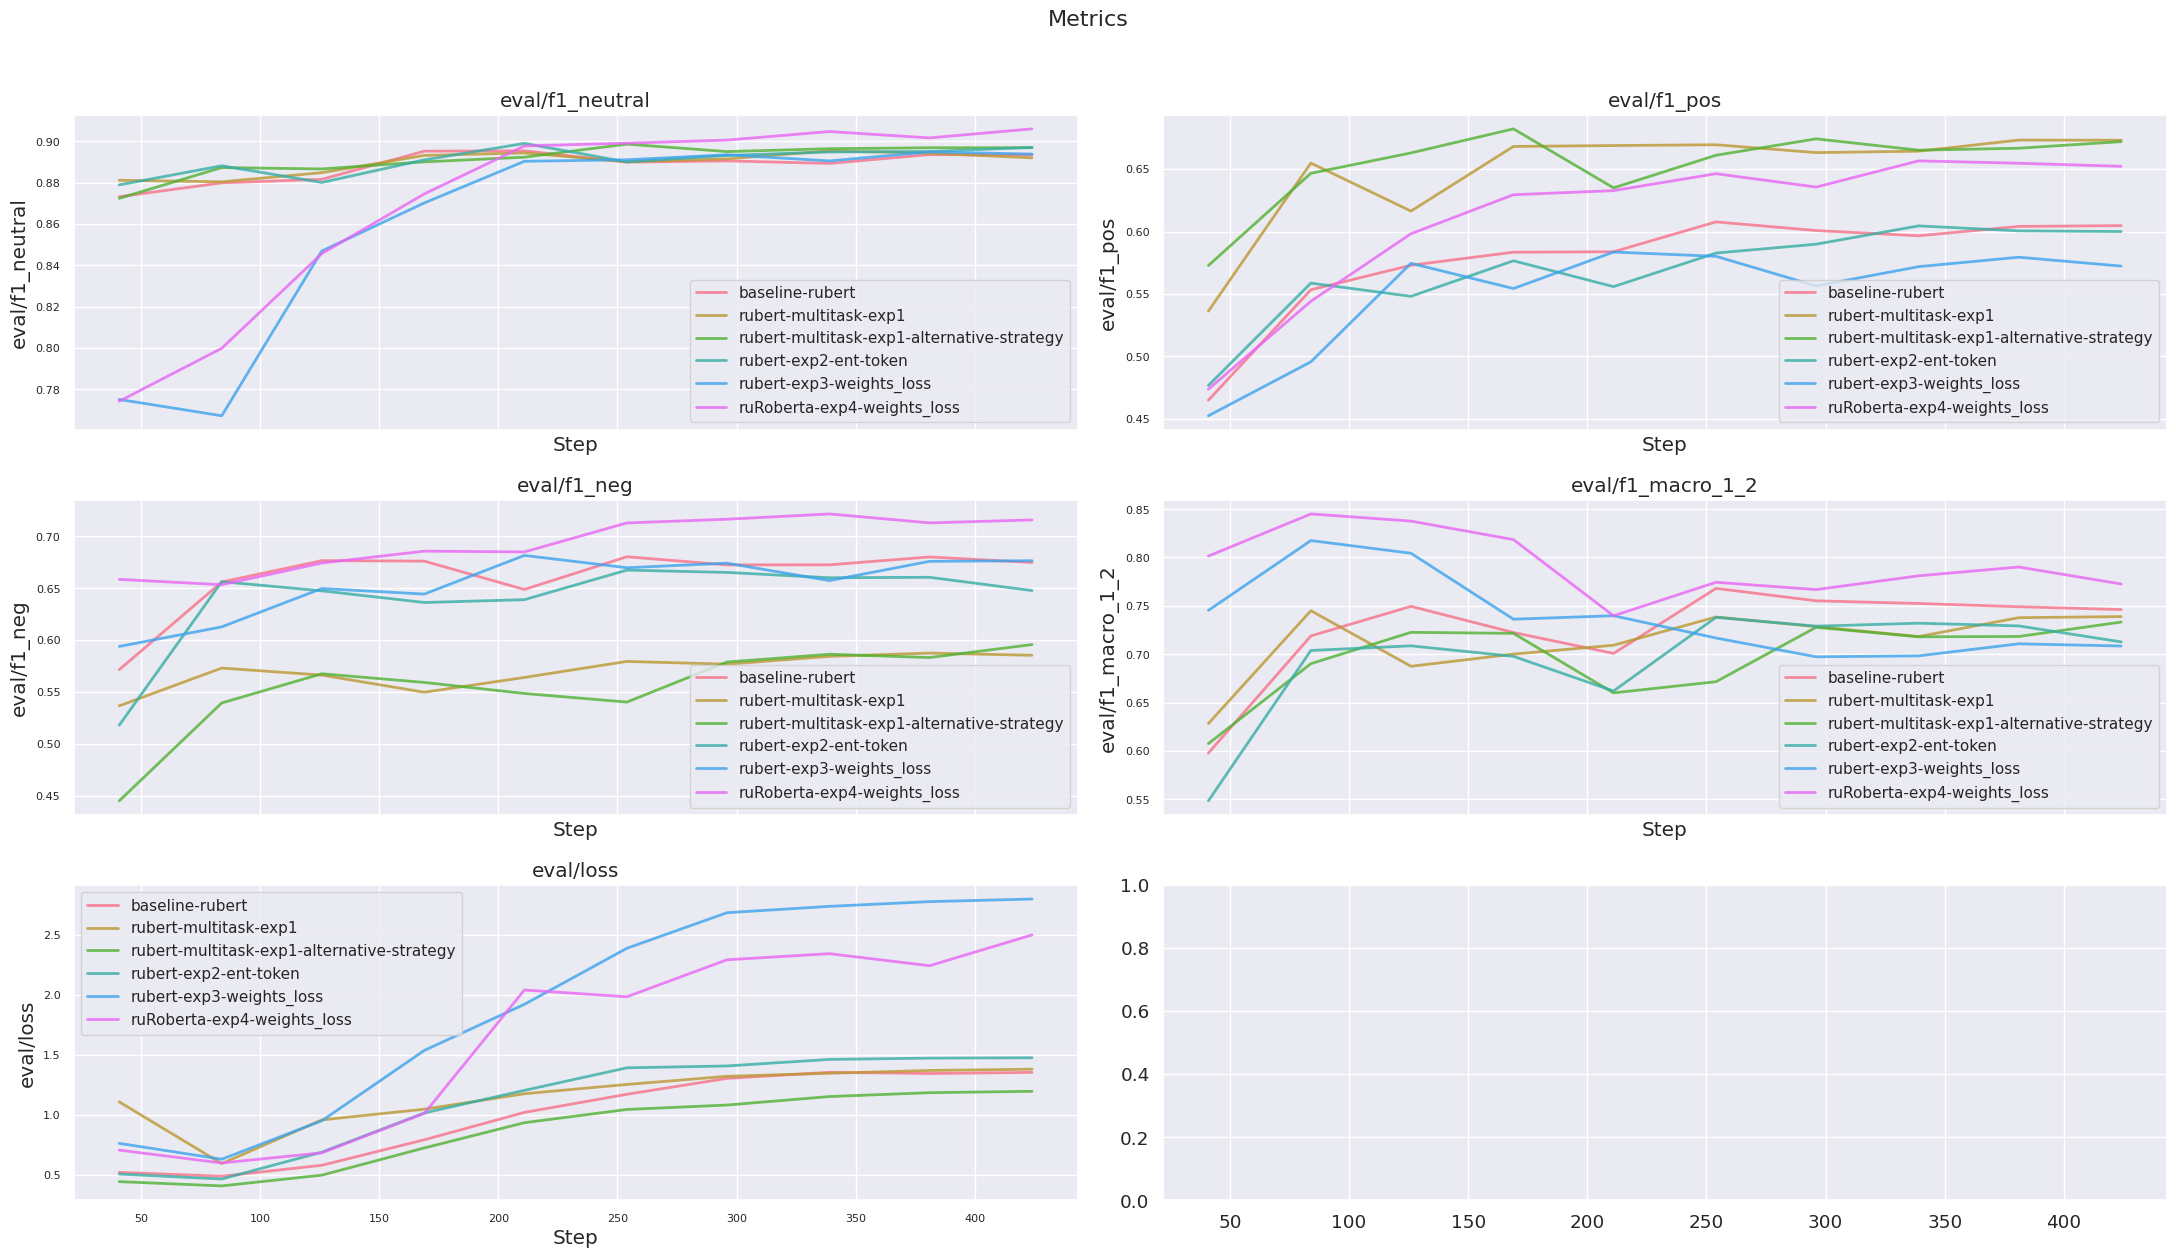

In [37]:
fig, axes = plt.subplots(3, 2, figsize=(22, 12), sharex=True)
axes = axes.flatten()

for idx, metric in enumerate(metrics):
    ax = axes[idx]
    for run_id in df["run_id"].unique():
        run_data = df[df["run_id"] == run_id]
        if metric in run_data.columns:
            ax.plot(
                run_data["_step"], 
                run_data[metric], 
                label=f"{run_data['run_name'].iloc[0]}", 
                linewidth=2, 
                alpha=0.8
            )
    
    ax.set_title(metric)
    ax.set_xlabel("Step")
    ax.set_ylabel(metric)
    ax.grid(True)
    ax.legend(fontsize=11, loc='best')
    ax.tick_params(axis='both', which='major', labelsize=8)

plt.tight_layout()
fig.suptitle("Metrics", fontsize=16, y=1.05)

plt.show()

Существенная проблема - сильное переобучение моделей. Датасет маленький, модели достаточно тяжелые

## Часть 2.

Современные виртуальные ассистенты &mdash; это сложные системы, состоящие на самом деле из большого количества моделей. Так, например, если мы говорим о голосовых ассистентах, то после запроса пользователя могут решаться следующие задачи:
* распознавание речи,
* предобработка текста,
* распознавание именованных сущностей, намерения пользователя,
* переход в другой навык (сервис), переключение на другую модель.

В этой задаче мы будем пытаться построить свою небольшую модель для распознавания намерения пользователя. Предположим, что в нашего бота Физтех.Статистики мы думаем добавить функциональности. Для каждого запроса на **естественном языке** мы хотим понять намерение пользователя, чтобы связать этот запрос с имеющимися сценариями. Например по запросам "когда дедлайны", "когда следующая лекция", "кому писать с вопросом по большой домашке" мы бы переключались на заготовленный сценарий взаимодействия без необходимости подключения преподавателя. Таким образом, наш роутинг запроса на самом деле сводится к задаче классификации текста, но с некоторыми особенностями. Обычно таких сервисов и сценариев много, при этом к уже имеющимся с течением времени добавляются новые. Возникает необходимость уметь быстро дообучать модель, добавляя новые классы, но и делать это так, чтобы качество для старых оставалось приемлемым.



![intent](https://f.hubspotusercontent20.net/hubfs/2734675/Intent-Classification-blog-images.jpg)

Будем работать с [данными](https://www.kaggle.com/datasets/constantinwerner/qa-intents-dataset-university-domain), которые собраны Новосибирским Государственным Университетом для своего QA-чатбота. Выбор в большой степени обусловлен именно "студенческим доменом". Описание гласит, что датасет содержит 142 интента (класса) и порядка 50-220 фраз на русском языке для каждого.

   0. Проведите небольшую аналитику имеющихся данных. Какой размер датасета? Сколько в среднем у нас имеется примеров на класс?  Что можно сказать насчет длины текстов, с которыми придется работать? С какими запросами приходится иметь дело?

   1. Для начала обучите какую-нибудь модель на основе архитектуры трансформер (например BERT-based модель для русского языка) целиком на исходном датасете. Не забудьте про валидацию. Измерьте качество на тестовой выборке. В качестве целевой метрики используйте точность.

   2. Далее попробуем имитировать следующий сетап. Предположим, что сначала у нас имеется 122 класса, к которым в течение времени планируется добавить еще 20 (а потом может быть еще). Выделите начальные 122 класса и обучите сначала модель на них. Посчитайте точность на тесте. Теперь, когда нам потребуется добавить новые интенты, нам бы не хотелось обучать модель заново, так как это может занять много времени, делать это придется довольно часто, а научиться поддерживать новые сценарии хотелось бы быстро. Мы поступим следующим образом:
       * Будем обучать только слой для классификации. При добавлении новых классов к нему добавляются лишь новые случайно инициализированные строки(столбцы), большой трансформер при этом остается замороженным.
       * Для еще большего ускорения процесса дообучения данные, которые соответствуют "первым" 122 классам можно предварительно пропустить через трансформер, а полученные скрытые состояния сохранить на диск. Таким образом, при появлении новых интентов и данных к ним через замороженный трансформер потребуется прогнать лишь новые тексты.
       * Проведите процесс дообучения на данных, соответствующим всем 142 классам, с учетом вышеизложенных предложений.
       * Сравните получившуюся модель на тестовой выборки с моделью из первого пункта.
    
4. Проведите **один** эксперимент, в котором вы можете:
    * Поэкспериментировать с разными головами для классификации (линейный слой, двухслойный MLP) и пуллингами (`[CLS]`, Mean-pooling).
    * Провести агументации запросов с использованием [augmentex](https://github.com/ai-forever/augmentex). Какие из агументаций наиболее полезны для нашего случая?

5. Сравните результаты с точки зрения значения целевой метрики, а также эффективности по времени обучения и дообучения для разных подходов. Какие плюсы и минусы описанного в втором пункте метода? Какие улучшения вы можете предложить? Попробуйте найти, например, релевантные статьи или блог-посты.

### Небольшая аналитика данных

Считаем данные

In [3]:
train = pd.read_csv('second_task/dataset_train.tsv', delimiter='\t',
                    encoding="utf-8",
                    names=['text', 'label'])
val = pd.read_csv('second_task/dataset_test.tsv', delimiter='\t',
                  encoding="utf-8",
                  names=['text', 'label'])
train.head()

,text,label
0,мне нужна справка,statement_general
1,оформить справку,statement_general
2,взять справку,statement_general
3,справку как получить,statement_general
4,справку ммф где получаться,statement_general


Размеры датасетов

In [4]:
train.shape, val.shape

((13230, 2), (883, 2))

Распределение длин

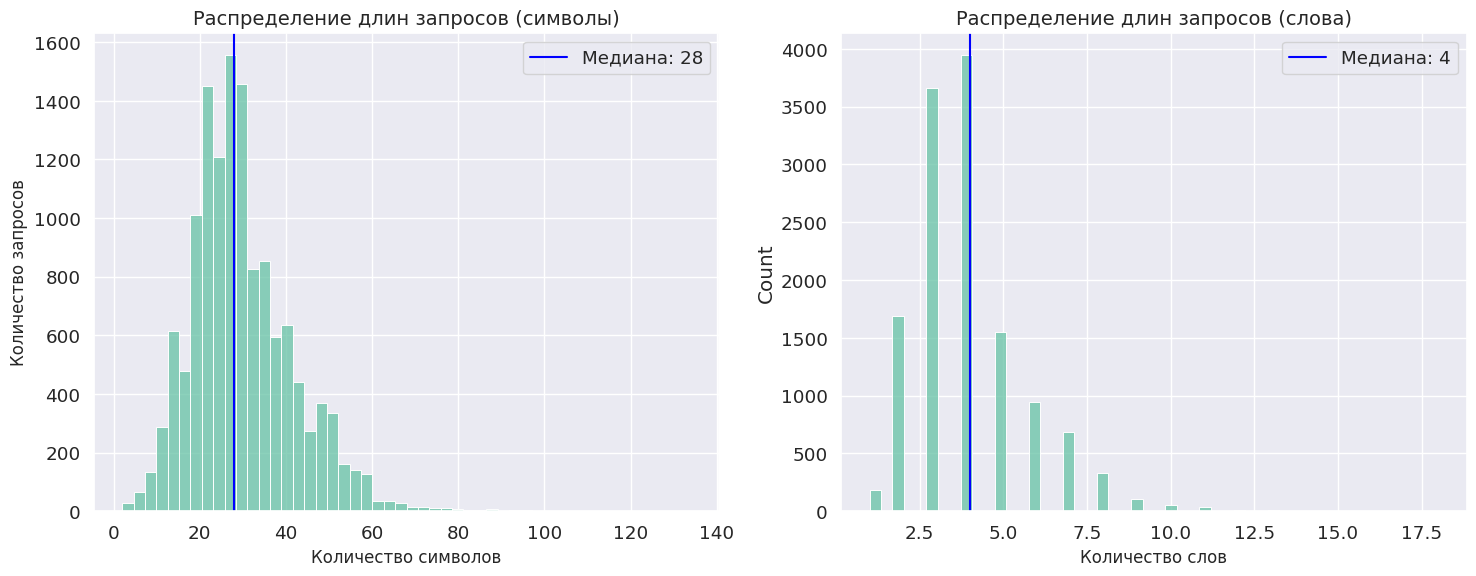

In [5]:
char_lens = train["text"].str.len().values

word_lens = train["text"].str.split().str.len().values

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

sns.histplot(char_lens, bins=50, ax=ax1)
ax1.set_title("Распределение длин запросов (символы)", fontsize=14)
ax1.set_xlabel("Количество символов", fontsize=12)
ax1.set_ylabel("Количество запросов", fontsize=12)

sns.histplot(word_lens, bins=50, ax=ax2)
ax2.set_title("Распределение длин запросов (слова)", fontsize=14)
ax2.set_xlabel("Количество слов", fontsize=12)

char_median = np.median(char_lens)
ax1.axvline(char_median, color='blue', linestyle='-', label=f'Медиана: {int(char_median)}')
ax1.legend()


word_median = np.median(word_lens)
ax2.axvline(word_median, color='blue', linestyle='-', label=f'Медиана: {int(word_median)}')
ax2.legend()

plt.tight_layout()

plt.show()

Запросы в среднем короткие, ~30 символов и ~5 слов

Распределение количества запросов по топикам. Как видно, топиков много, визуализирую лишь топ-20. 

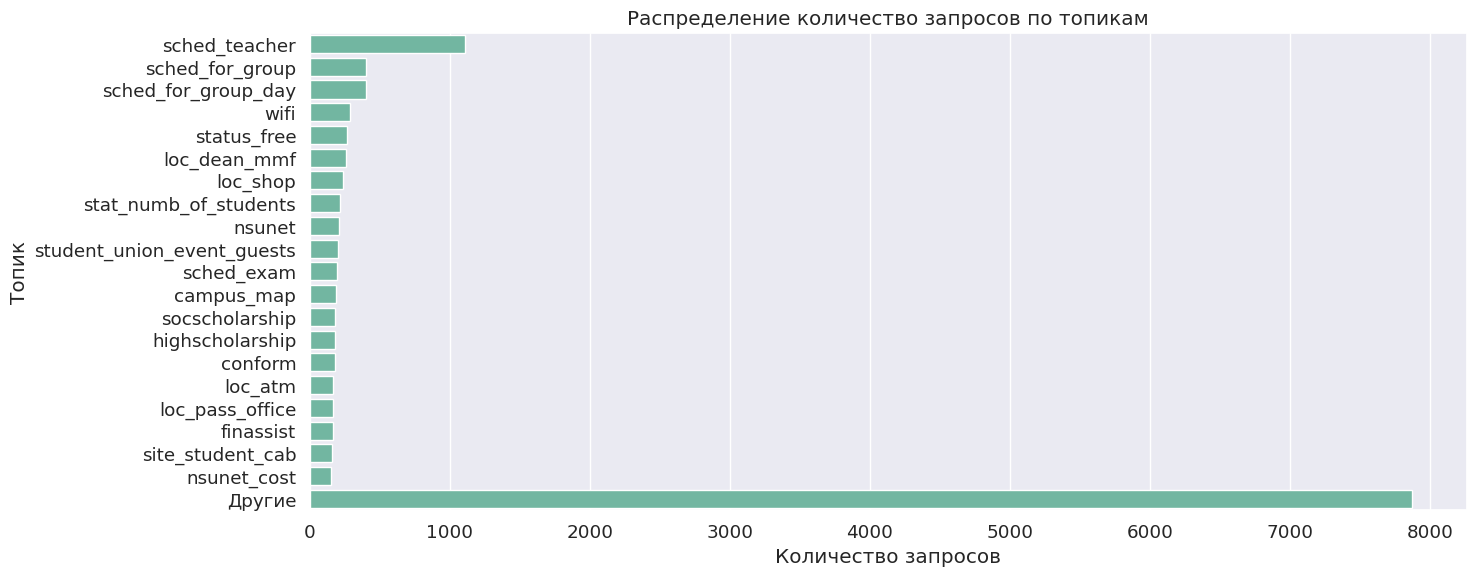

In [6]:
topic_counts = train['label'].value_counts().sort_values(ascending=False)

top_n = 20
top_topics = topic_counts.head(top_n)
other_sum = topic_counts.iloc[top_n:].sum()
top_topics['Другие'] = other_sum

plt.figure(figsize=(15, 6))
sns.barplot(x=top_topics.values, y=top_topics.index)
plt.title('Распределение количество запросов по топикам')
plt.xlabel('Количество запросов')
plt.ylabel('Топик')
plt.tight_layout()
plt.show()

Что касается статистик:

In [7]:
median_requests = topic_counts.median()
min_requests = topic_counts.min()
max_requests = topic_counts.max()

print(f"Статистики количества запросов на топик:")
print(f"Медиана: {median_requests:.2f}")
print(f"Минимум: {min_requests}")
print(f"Максимум: {max_requests}")
print(f"Общее количество топиков: {len(topic_counts)}")

Статистики количества запросов на топик:
Медиана: 65.00
Минимум: 20
Максимум: 1110
Общее количество топиков: 142


### Baseline

Подготавливаю данные

In [25]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

train_df = train.copy()
val_df = val.copy()

train_df['label_name'] = train_df['label']
val_df['label_name'] = val_df['label']

train_df['label'] = label_encoder.fit_transform(train_df['label'])
val_df['label'] = label_encoder.transform(val_df['label'])


num_labels = len(label_encoder.classes_)

Датасеты

In [27]:
tokenizer = AutoTokenizer.from_pretrained("DeepPavlov/rubert-base-cased")

def tokenize(batch):
    return tokenizer(batch["text"], truncation=True)

train_dataset = datasets.Dataset.from_pandas(train_df[['text', 'label']])
val_dataset = datasets.Dataset.from_pandas(val_df[['text', 'label']])

train_dataset = train_dataset.map(tokenize, batched=True, num_proc=4)
val_dataset = val_dataset.map(tokenize, batched=True, num_proc=4)

print(train_dataset[0])

Map (num_proc=4):   0%|          | 0/13230 [00:00<?, ? examples/s]

Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.
Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.
Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.
Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.


Map (num_proc=4):   0%|          | 0/883 [00:00<?, ? examples/s]

Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.
Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.
Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.
Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.


{'text': 'мне нужна справка', 'label': 114, 'input_ids': [101, 16740, 40692, 12816, 1714, 102], 'token_type_ids': [0, 0, 0, 0, 0, 0], 'attention_mask': [1, 1, 1, 1, 1, 1]}


Метрики

In [23]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

def compute_metrics(pred):
    predictions, labels = pred
    preds = np.argmax(predictions, axis=1)
    acc = accuracy_score(labels, preds)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average='macro')
    
    return {
        "accuracy": acc,
        "precision_macro": precision,
        "recall_macro": recall,
        "f1_macro": f1
    }

Иницализация обучения

In [11]:
training_args = TrainingArguments(
    output_dir="./checkpoints_exp1",
    num_train_epochs=10,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_dir="./logs",
    logging_steps=10,
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    report_to="wandb",
    run_name="rubert-multitask",
    learning_rate=2e-5,
    weight_decay=0.01,
    push_to_hub=False,
    save_total_limit=1
)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

model = AutoModelForSequenceClassification.from_pretrained(
    "DeepPavlov/rubert-base-cased",
    num_labels=num_labels
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at DeepPavlov/rubert-base-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Обучение

In [101]:
wandb.init(project="label-classification", name="baseline-rubert")
trainer.train()
wandb.finish()

train/epoch,▁▁▂▂▂▂▂▃▃▃▃▄▄▄▅▅▅▅▅▆▆▆▆▇▇▇▇██
train/global_step,▁▁▁▂▂▂▃▃▃▃▃▄▄▄▅▅▅▅▅▆▆▆▇▇▇▇▇██
train/grad_norm,▁▂▃█▃▄▄▄▅▄▄▅▅▅▄▅▄▅▅▄▄▄▄▅▄▄▄▄▄
train/learning_rate,██▇▇▇▇▇▆▆▆▆▅▅▅▅▄▄▄▃▃▃▃▃▂▂▂▂▁▁
train/loss,███▇▇▇▇▆▆▆▅▅▅▄▅▄▅▃▃▃▃▃▂▂▃▂▂▁▁
train/epoch,0.35067
train/global_step,290
train/grad_norm,6.6055
train/learning_rate,2e-05
train/loss,2.941


Epoch,Training Loss,Validation Loss,Accuracy,Precision Macro,Recall Macro,F1 Macro
1,1.337200,1.125057,0.873160,0.768333,0.770888,0.755207
2,0.314500,0.287940,0.950170,0.918820,0.927862,0.919634
3,0.147800,0.144604,0.956965,0.939151,0.948430,0.941206
4,0.130900,0.109404,0.959230,0.950085,0.956940,0.951241
5,0.061200,0.100387,0.961495,0.958142,0.964032,0.959013
6,0.111400,0.096052,0.960362,0.957965,0.964032,0.958751
7,0.127800,0.094189,0.960362,0.957965,0.964032,0.958751
8,0.114500,0.093062,0.960362,0.957965,0.964032,0.958751
9,0.081600,0.094812,0.959230,0.951219,0.955483,0.950993
10,0.102000,0.091413,0.959230,0.951219,0.955483,0.950993


/home/juequ/.local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/juequ/.local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/juequ/.local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/juequ/.local/lib/py

eval/accuracy,▁▇████████
eval/f1_macro,▁▇▇███████
eval/loss,█▂▁▁▁▁▁▁▁▁
eval/precision_macro,▁▇▇███████
eval/recall_macro,▁▇▇███████
eval/runtime,██▆▄▇▇▇▆▄▁
eval/samples_per_second,▁▁▃▅▂▂▂▃▅█
eval/steps_per_second,▁▁▃▅▂▂▂▃▅█
train/epoch,▁▁▁▁▁▁▂▂▂▂▂▂▂▂▃▃▃▄▄▄▅▅▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇██
train/global_step,▁▁▁▁▁▂▂▃▄▄▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇█
train/grad_norm,██▅▇▅▆▃▅▅▄▃▃▅▃▁▁▁▁▃▃▄▄▁▁▁▁▄▄▁▃▁▄▁▅▃▁▁▄▃▄


Точность в 0.96 - мы очень хорошо решаем задачу

### Обучаем на подмножестве классов

In [31]:
base_classes = label_encoder.classes_[:-20]
other_classes = label_encoder.classes_[-20:]

print("Базовые классы:", base_classes)
print("Оставшиеся классы:", other_classes)

Базовые классы: ['advice_learning' 'advice_okno' 'campus_map' 'conform' 'cvvr_define'
 'diploma_red_def' 'dorm_enter_without_pass' 'dorm_guests' 'dorm_living'
 'dorm_pets' 'dorm_price' 'dormcard_lost' 'enter_university_without_pass'
 'events_define' 'exam_define' 'finassist' 'find_friends' 'grade_improve'
 'grade_mistake' 'highscholarship' 'holidays_def' 'incomestat'
 'library_books' 'list_orders' 'loc_accounting' 'loc_atm'
 'loc_automationelectrometryinstitute'
 'loc_cafeteria_new_building_1_etage' 'loc_cafeteria_new_building_2_etage'
 'loc_cafeteria_new_building_3_etage' 'loc_cafeteria_new_building_4_etage'
 'loc_cafeteria_new_building_general' 'loc_cafeteria_old_building'
 'loc_cashbox' 'loc_chiminstitute' 'loc_clinic' 'loc_commissariat'
 'loc_compcenter' 'loc_coworking' 'loc_cytologygeneticsinstitute'
 'loc_dean_ef' 'loc_dean_fen' 'loc_dean_ff' 'loc_dean_fit'
 'loc_dean_general' 'loc_dean_ggf' 'loc_dean_hi' 'loc_dean_med'
 'loc_dean_mmf' 'loc_dean_ph' 'loc_dorm' 'loc_eat'
 'loc_geo

Сформируем датасеты

In [32]:
base_train_dataset = datasets.Dataset.from_pandas(train_df[train_df['label_name'].isin(base_classes)][['text', 'label']])
base_val_dataset = datasets.Dataset.from_pandas(val_df[val_df['label_name'].isin(base_classes)][['text', 'label']])

base_train_dataset = base_train_dataset.map(tokenize, batched=True, num_proc=4)
base_val_dataset = base_val_dataset.map(tokenize, batched=True, num_proc=4)

print(base_train_dataset[0])

Map (num_proc=4):   0%|          | 0/11467 [00:00<?, ? examples/s]

Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.
Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.
Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.
Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.


Map (num_proc=4):   0%|          | 0/767 [00:00<?, ? examples/s]

Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.
Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.
Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.
Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.


{'text': 'мне нужна справка', 'label': 114, '__index_level_0__': 0, 'input_ids': [101, 16740, 40692, 12816, 1714, 102], 'token_type_ids': [0, 0, 0, 0, 0, 0], 'attention_mask': [1, 1, 1, 1, 1, 1]}


Модель

In [33]:
model = AutoModelForSequenceClassification.from_pretrained(
    "DeepPavlov/rubert-base-cased",
    num_labels=num_labels - 20
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=base_train_dataset,
    eval_dataset=base_val_dataset,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at DeepPavlov/rubert-base-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Обучаем

In [34]:
wandb.init(project="label-classification", name="rubert-base-classes")
trainer.train()
wandb.finish()

wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.
wandb: Currently logged in as: ermolaevfedor (juequ). Use `wandb login --relogin` to force relogin


Epoch,Training Loss,Validation Loss,Accuracy,Precision Macro,Recall Macro,F1 Macro
1,1.227800,1.065233,0.864407,0.696914,0.731359,0.701474
2,0.357800,0.289304,0.950456,0.938030,0.941558,0.935448
3,0.190800,0.151474,0.954368,0.949846,0.953955,0.948732
4,0.087800,0.120505,0.955671,0.951224,0.958087,0.952238
5,0.082800,0.115242,0.955671,0.951224,0.958087,0.952238
6,0.123700,0.109136,0.955671,0.951224,0.958087,0.952238
7,0.140900,0.107362,0.954368,0.951017,0.958087,0.951933
8,0.100100,0.108969,0.954368,0.949846,0.956434,0.950569
9,0.085100,0.102614,0.954368,0.950580,0.957399,0.951596
10,0.050200,0.104796,0.954368,0.951017,0.958087,0.951933


/home/juequ/.local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/juequ/.local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/juequ/.local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/juequ/.local/lib/py

eval/accuracy,▁█████████
eval/f1_macro,▁█████████
eval/loss,█▂▁▁▁▁▁▁▁▁
eval/precision_macro,▁█████████
eval/recall_macro,▁▇████████
eval/runtime,▆▁▄█▇▅▄▂▂▁
eval/samples_per_second,▃█▅▁▂▄▄▇▇█
eval/steps_per_second,▃█▅▁▂▄▄▇▇█
train/epoch,▁▁▁▁▁▂▂▂▂▂▃▃▃▃▄▄▄▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇███
train/global_step,▁▁▁▁▁▂▂▂▂▂▂▂▃▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▇▇▇██
train/grad_norm,▇▇▇█▆▆▆▄▄▅▂▄▂▁▂▂▁▂▁▁▁▂▂▃▂▁▂▂▁▁▂▁▂▁▁▁▃▃▁▁


Сохраним скрытые состояния. Только уже сразу и старых, и новых классов. Считаем, что мы просто через трансформер прогоняем только новые данные, и склеиваем со старыми.

Вспомогательный коллокатор. Будем сохранять `label`

In [45]:
def custom_collator(batch):
    tokenized = [{k: v for k, v in item.items() if k in ['input_ids', 'token_type_ids', 'attention_mask']} for item in batch]
    labels = [item['label'] for item in batch]
    collator = DataCollatorWithPadding(tokenizer=tokenizer)
    batch = collator(tokenized)
    batch['label'] = torch.stack(labels)
    return batch

Подсчет скрытых состояний

In [44]:
train_dataset.set_format(
    type="torch",
    columns=["input_ids", "token_type_ids", "attention_mask", "label"]
)
val_dataset.set_format(
    type="torch",
    columns=["input_ids", "token_type_ids", "attention_mask", "label"]
)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    collate_fn=custom_collator
)
val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    collate_fn=custom_collator
)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

base_model = model.base_model
base_model.eval()
for p in base_model.parameters():
    p.requires_grad = False

# Train
hidden_states = []
labels_list    = []

with torch.no_grad():
    for batch in tqdm(train_loader):
        outputs = base_model(
            input_ids=batch["input_ids"].to(device),
            token_type_ids=batch["token_type_ids"].to(device),
            attention_mask=batch["attention_mask"].to(device),
            return_dict=True
        )
        cls_emb = outputs.last_hidden_state[:, 0, :].cpu()  
        hidden_states.append(cls_emb)
        labels_list.append(batch["label"])

hidden_states = torch.cat(hidden_states, dim=0)
all_labels    = torch.cat(labels_list, dim=0)

torch.save({
    "embeddings": hidden_states,
    "labels":     all_labels
}, "train_hidden_states.pt")

# Validation
hidden_states = []
labels_list    = []

with torch.no_grad():
    for batch in tqdm(val_loader):
        outputs = base_model(
            input_ids=batch["input_ids"].to(device),
            token_type_ids=batch["token_type_ids"].to(device),
            attention_mask=batch["attention_mask"].to(device),
            return_dict=True
        )
        cls_emb = outputs.last_hidden_state[:, 0, :].cpu()  
        hidden_states.append(cls_emb)
        labels_list.append(batch["label"])

hidden_states = torch.cat(hidden_states, dim=0)
all_labels    = torch.cat(labels_list, dim=0)

torch.save({
    "embeddings": hidden_states,
    "labels":     all_labels
}, "val_hidden_states.pt")

  0%|          | 0/414 [00:00<?, ?it/s]

  0%|          | 0/28 [00:00<?, ?it/s]

Добавим новые столбцы в классификатор

In [51]:
old_classifier = model.classifier
hidden_size = old_classifier.in_features

new_classifier = nn.Linear(hidden_size, num_labels)

with torch.no_grad():
    new_classifier.weight[:-20] = old_classifier.weight
    new_classifier.bias[:-20] = old_classifier.bias

new_classifier = new_classifier.to(device)

Классы-обертки

In [52]:
class EmbeddingDataset(Dataset):
    def __init__(self, embeddings, labels):
        self.embeddings = embeddings
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            "embeddings": self.embeddings[idx],
            "labels": self.labels[idx]
        }

class ClassifierModel(nn.Module):
    def __init__(self, classifier):
        super(ClassifierModel, self).__init__()
        self.classifier = classifier

    def forward(self, embeddings, labels=None):
        outputs = self.classifier(embeddings)
        loss = None
        if labels is not None:
            loss = nn.CrossEntropyLoss()(outputs, labels)
        return (loss, outputs) if loss is not None else outputs

Теперь обучим новый классификатор. Сначала создадим датасеты и модель

In [53]:
train_new_classifier = torch.load("train_hidden_states.pt")
val_new_classifier = torch.load("val_hidden_states.pt")

train_embeddings = train_new_classifier["embeddings"]
train_labels = train_new_classifier["labels"]
val_embeddings = val_new_classifier["embeddings"]
val_labels = val_new_classifier["labels"]

train_new_classifier_dataset = EmbeddingDataset(train_embeddings, train_labels)
val_new_classifier_dataset  = EmbeddingDataset(train_embeddings, train_labels)

new_classifier_model = ClassifierModel(new_classifier)

/tmp/ipykernel_642/2786815394.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  train_new_classifier = torch.load("train_hidden_states.pt")
/tmp/ipykernel_642/2786815394.p

Обучение

In [54]:
training_args = TrainingArguments(
    output_dir="./checkpoints_exp1",
    num_train_epochs=20,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_dir="./logs",
    logging_steps=10,
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    report_to="wandb",
    run_name="rubert-all-classes",
    learning_rate=2e-5,
    weight_decay=0.01,
    push_to_hub=False,
    save_total_limit=1
)

trainer = Trainer(
    model=new_classifier_model,
    args=training_args,
    train_dataset=train_new_classifier_dataset,
    eval_dataset=val_new_classifier_dataset,
    compute_metrics=compute_metrics,
)

wandb.init(project="label-classification", name="rubert-all-classes")
trainer.train()
wandb.finish()

Epoch,Training Loss,Validation Loss,Accuracy,Precision Macro,Recall Macro,F1 Macro
1,2.521600,2.529097,0.804082,0.646638,0.688535,0.648884
2,1.172900,1.202247,0.874754,0.810966,0.829573,0.804624
3,0.678000,0.666650,0.892668,0.866892,0.865134,0.846208
4,0.458300,0.442750,0.904989,0.896129,0.887676,0.875262
5,0.359600,0.337694,0.912623,0.906542,0.902379,0.891490
6,0.326900,0.281427,0.918821,0.917090,0.911704,0.902590
7,0.244900,0.247379,0.924036,0.920628,0.918227,0.910428
8,0.249500,0.224656,0.927740,0.925379,0.924211,0.917415
9,0.197000,0.208433,0.931444,0.928335,0.929671,0.922618
10,0.112700,0.196244,0.933787,0.931826,0.932477,0.926300


/home/juequ/.local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/juequ/.local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/juequ/.local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/juequ/.local/lib/py

eval/accuracy,▁▅▆▆▇▇▇▇▇███████████
eval/f1_macro,▁▅▆▆▇▇▇▇████████████
eval/loss,█▄▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
eval/precision_macro,▁▅▆▇▇▇██████████████
eval/recall_macro,▁▅▆▆▇▇▇▇████████████
eval/runtime,▁▂▂▂▂▁▂▁▃▁█▂▂▁▂▂▂▂▂▂
eval/samples_per_second,█▆▅▅▅▇▆█▄▇▁▅▆█▅▆▅▆▆▅
eval/steps_per_second,█▆▅▅▅▇▆█▄▇▁▅▆█▅▆▅▆▆▅
train/epoch,▁▁▁▁▁▂▂▂▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▅▅▆▆▆▆▇▇▇▇▇▇▇▇▇▇█
train/global_step,▁▁▁▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇▇▇▇████
train/grad_norm,█▅▄▄▄▃▃▂▃▃▄▃▂▃▃▁▄▂▃▃▂▃▄▃▂▃▁▂▁▂▃▁▁▂▂▂▂▃▃▂


1 эпоха обучается в ~10 раз быстрее, это очень хорошо. Однако у нас чуть худшее качество - 0.94 против 0.96 бейзлана. Проблема в том, что сами эмбендинги не дообучаются для задачи классификации нужных тем. Как вариант исправления - можно дообучать несколько последних слоев модели / сделать более сложный классификатор / пулинг несколько токенов.

### Эксперимент

Сделаю классификатор более сложным, но предиктить все равно буду только по CLS. Это оправдано, потому что запросы короткие - пулинг сильно помочь не сможет, в [CLS] уже достаточно информации о запросе. Проблема в том, что она ""не совсем подходящая"" для классификации нужных классов - хочется, чтобы в эмбендингах самих по себе была чуть другая информация. Вытаскивать более нужную как раз поможет усложненная голова.

Модифицированная модель

In [57]:
class RubertMLPClassifier(nn.Module):
    def __init__(self, model_name="DeepPavlov/rubert-base-cased",
                 num_classes=2, mlp_hidden=256):
        super().__init__()
        self.bert = AutoModel.from_pretrained(model_name)
        self.dropout = nn.Dropout(0.1)
        self.hidden_size = self.bert.config.hidden_size
        self.mlp_hidden_size = mlp_hidden
        self.num_classes = num_classes
        self.classifier = nn.Sequential(
            nn.Dropout(0.1),
            nn.Linear(self.hidden_size, self.mlp_hidden_size),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(self.mlp_hidden_size, num_classes)
        )

    def forward(self, input_ids, attention_mask, labels=None):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        cls_output = self.dropout(outputs.last_hidden_state[:, 0, :]) 

        logits = self.classifier(cls_output)

        loss = None
        if labels is not None:
            loss_fn = nn.CrossEntropyLoss()
            loss = loss_fn(logits, labels)

        return {
            "loss": loss,
            "logits": logits,
        }

Инициализация обучения

In [58]:
training_args = TrainingArguments(
    output_dir="./checkpoints_exp1",
    num_train_epochs=10,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_dir="./logs",
    logging_steps=10,
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    report_to="wandb",
    run_name="rubert-sub",
    learning_rate=2e-5,
    weight_decay=0.01,
    push_to_hub=False,
    save_total_limit=1
)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

model = RubertMLPClassifier(
    model_name="DeepPavlov/rubert-base-cased",
    num_classes=num_labels - 20
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=base_train_dataset,
    eval_dataset=base_val_dataset,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

Some weights of the model checkpoint at DeepPavlov/rubert-base-cased were not used when initializing BertModel: ['cls.predictions.bias', 'cls.predictions.decoder.bias', 'cls.predictions.decoder.weight', 'cls.predictions.transform.LayerNorm.bias', 'cls.predictions.transform.LayerNorm.weight', 'cls.predictions.transform.dense.bias', 'cls.predictions.transform.dense.weight', 'cls.seq_relationship.bias', 'cls.seq_relationship.weight']
- This IS expected if you are initializing BertModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


Запуск обучения

In [59]:
wandb.init(project="label-classification", name="rubert-base-classes-exp1")
trainer.train()
wandb.finish()

Epoch,Training Loss,Validation Loss,Accuracy,Precision Macro,Recall Macro,F1 Macro
1,1.307800,1.001566,0.874837,0.728932,0.755562,0.732623
2,0.343600,0.247010,0.951760,0.947711,0.952302,0.946193
3,0.161200,0.137290,0.954368,0.949158,0.956434,0.950139
4,0.077100,0.121549,0.954368,0.951279,0.956434,0.952375
5,0.083200,0.118062,0.953064,0.949105,0.954683,0.949208
6,0.127500,0.113737,0.954368,0.949964,0.956434,0.950737
7,0.159900,0.115507,0.954368,0.949846,0.956434,0.950569
8,0.097200,0.114110,0.954368,0.949846,0.956434,0.950569
9,0.090300,0.111575,0.947849,0.948532,0.951614,0.948770
10,0.053200,0.115103,0.953064,0.949640,0.956434,0.950263


/home/juequ/.local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/juequ/.local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/juequ/.local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/juequ/.local/lib/python3.10

eval/accuracy,▁███████▇█
eval/f1_macro,▁█████████
eval/loss,█▂▁▁▁▁▁▁▁▁
eval/precision_macro,▁█████████
eval/recall_macro,▁█████████
eval/runtime,▁▂▁▃▃█▃▄▃▃
eval/samples_per_second,█▇█▆▆▁▆▄▆▅
eval/steps_per_second,█▇█▆▆▁▆▄▆▅
train/epoch,▁▁▁▁▁▂▂▂▂▂▂▃▃▃▄▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇███
train/global_step,▁▂▂▂▂▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▆▆▇▇▇▇▇▇██████
train/grad_norm,▆▆█▆▆▆▄▄▄▃▁▃▂▁▃▂▁▁▃▅▁▁▃▃▁▁▃▃▁▃▃▁▅▃▃▃▃▁▃▁


Качество на базовых классов не изменилось.

Сохраним эмбендинги

In [60]:
base_model = model.bert
base_model.eval()
for p in base_model.parameters():
    p.requires_grad = False

# Train
hidden_states = []
labels_list    = []

with torch.no_grad():
    for batch in tqdm(train_loader):
        outputs = base_model(
            input_ids=batch["input_ids"].to(device),
            token_type_ids=batch["token_type_ids"].to(device),
            attention_mask=batch["attention_mask"].to(device),
            return_dict=True
        )
        cls_emb = outputs.last_hidden_state[:, 0, :].cpu()  
        hidden_states.append(cls_emb)
        labels_list.append(batch["label"])

hidden_states = torch.cat(hidden_states, dim=0)
all_labels    = torch.cat(labels_list, dim=0)

torch.save({
    "embeddings": hidden_states,
    "labels":     all_labels
}, "train_hidden_states.pt")

# Validation
hidden_states = []
labels_list    = []

with torch.no_grad():
    for batch in tqdm(val_loader):
        outputs = base_model(
            input_ids=batch["input_ids"].to(device),
            token_type_ids=batch["token_type_ids"].to(device),
            attention_mask=batch["attention_mask"].to(device),
            return_dict=True
        )
        cls_emb = outputs.last_hidden_state[:, 0, :].cpu()  
        hidden_states.append(cls_emb)
        labels_list.append(batch["label"])

hidden_states = torch.cat(hidden_states, dim=0)
all_labels    = torch.cat(labels_list, dim=0)

torch.save({
    "embeddings": hidden_states,
    "labels":     all_labels
}, "val_hidden_states.pt")

  0%|          | 0/414 [00:00<?, ?it/s]

  0%|          | 0/28 [00:00<?, ?it/s]

Добавим новые столбцы в классификатор

In [61]:
from copy import deepcopy

new_classifier = deepcopy(model.classifier) 
new_last_linear = nn.Linear(model.mlp_hidden_size, num_labels)

with torch.no_grad():
    new_last_linear.weight[:-20] = new_classifier[4].weight
    new_last_linear.bias[:-20] = new_classifier[4].bias

new_classifier[4] = new_last_linear
new_classifier = new_classifier.to(device)

Теперь обучим новый классификатор. Сначала создадим датасеты и модель

In [62]:
train_new_classifier = torch.load("train_hidden_states.pt")
val_new_classifier = torch.load("val_hidden_states.pt")

train_embeddings = train_new_classifier["embeddings"]
train_labels = train_new_classifier["labels"]
val_embeddings = val_new_classifier["embeddings"]
val_labels = val_new_classifier["labels"]

train_new_classifier_dataset = EmbeddingDataset(train_embeddings, train_labels)
val_new_classifier_dataset  = EmbeddingDataset(train_embeddings, train_labels)

new_classifier_model = ClassifierModel(new_classifier)

/tmp/ipykernel_642/2786815394.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  train_new_classifier = torch.load("train_hidden_states.pt")
/tmp/ipykernel_642/2786815394.p

Обучение

In [63]:
training_args = TrainingArguments(
    output_dir="./checkpoints_exp1",
    num_train_epochs=30,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_dir="./logs",
    logging_steps=10,
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    report_to="wandb",
    run_name="rubert-all-classes",
    learning_rate=2e-5,
    weight_decay=0.01,
    push_to_hub=False,
    save_total_limit=1
)

trainer = Trainer(
    model=new_classifier_model,
    args=training_args,
    train_dataset=train_new_classifier_dataset,
    eval_dataset=val_new_classifier_dataset,
    compute_metrics=compute_metrics,
)

wandb.init(project="label-classification", name="rubert-all-classes-exp1")
trainer.train()
wandb.finish()

Epoch,Training Loss,Validation Loss,Accuracy,Precision Macro,Recall Macro,F1 Macro
1,0.385200,0.387127,0.885563,0.835050,0.857939,0.833239
2,0.372500,0.283234,0.907105,0.873900,0.885426,0.869588
3,0.239200,0.233642,0.918141,0.906241,0.904807,0.893742
4,0.170600,0.206338,0.922147,0.910338,0.911077,0.903485
5,0.210700,0.186671,0.927589,0.928338,0.919239,0.912983
6,0.171000,0.173891,0.932048,0.931010,0.932658,0.926474
7,0.140400,0.166600,0.933258,0.931337,0.935416,0.928878
8,0.145400,0.159403,0.935374,0.939872,0.938030,0.931883
9,0.170900,0.153137,0.937264,0.937496,0.941523,0.935937
10,0.164000,0.148292,0.939607,0.939359,0.942923,0.936954


/home/juequ/.local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/juequ/.local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/juequ/.local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/juequ/.local/lib/py

eval/accuracy,▁▄▅▅▆▇▇▇▇▇▇▇█▇██▇█████████████
eval/f1_macro,▁▃▅▅▆▇▇▇██▇▇██████████████████
eval/loss,█▅▄▃▃▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
eval/precision_macro,▁▃▅▆▇▇▇▇▇▇▇▇█▇▇█▇▇▇██▇████████
eval/recall_macro,▁▃▅▅▆▇▇▇▇█████████████████████
eval/runtime,▂▅▂▁▅▂▂▂▁▂▁▂█▂▄▂▃▂▂▂▂▂▂█▄▂▂▂▂▂
eval/samples_per_second,▆▃▇█▃▆▆▇▇▇▇▆▁▆▄▇▆▇▇▆▇▆▆▁▄▆▆▇▆▆
eval/steps_per_second,▆▃▇█▃▆▆▇▇▇▇▆▁▆▄▇▆▇▇▆▇▆▆▁▄▆▆▇▆▆
train/epoch,▁▁▁▂▂▂▂▂▂▂▃▄▄▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▆▆▆▇▇▇▇▇▇▇█
train/global_step,▁▁▁▁▁▂▂▂▂▂▂▂▂▂▂▃▄▄▄▄▄▄▄▅▅▅▅▅▆▆▆▇▇▇▇▇████
train/grad_norm,▆▄▄▄▆▃▄▅▃▆▁▆▆▆▄▅▄▄▅▆▁▄▄▅▆▆▄▄▄▂▆▁▄▅▇▁▅▁█▂


Качество не улучшилось

### Итоговые графики

In [64]:
api = wandb.Api()

entity = "juequ"
project = "label-classification"

metrics = ["eval/accuracy", "eval/f1_macro", "eval/recall_macro", "eval/precision_macro",
           "eval/loss",
           "eval/steps_per_second"]

runs = api.runs(f"{entity}/{project}")

all_metrics_data = []

for run in runs:
    history = run.history(keys=metrics)
    if not history.empty:
        history["run_id"] = run.id
        history["run_name"] = run.name
        all_metrics_data.append(history)

df = pd.concat(all_metrics_data, ignore_index=True)
df.head()

,_step,eval/accuracy,eval/f1_macro,eval/recall_macro,eval/precision_macro,eval/loss,eval/steps_per_second,run_id,run_name
0,82,0.873160,0.755207,0.770888,0.768333,1.125057,45.659,ntlys47u,baseline-rubert
1,166,0.950170,0.919634,0.927862,0.918820,0.287940,45.353,ntlys47u,baseline-rubert
2,250,0.956965,0.941206,0.948430,0.939151,0.144604,47.204,ntlys47u,baseline-rubert
3,333,0.959230,0.951241,0.956940,0.950085,0.109404,49.420,ntlys47u,baseline-rubert
4,417,0.961495,0.959013,0.964032,0.958142,0.100387,46.211,ntlys47u,baseline-rubert


Графики

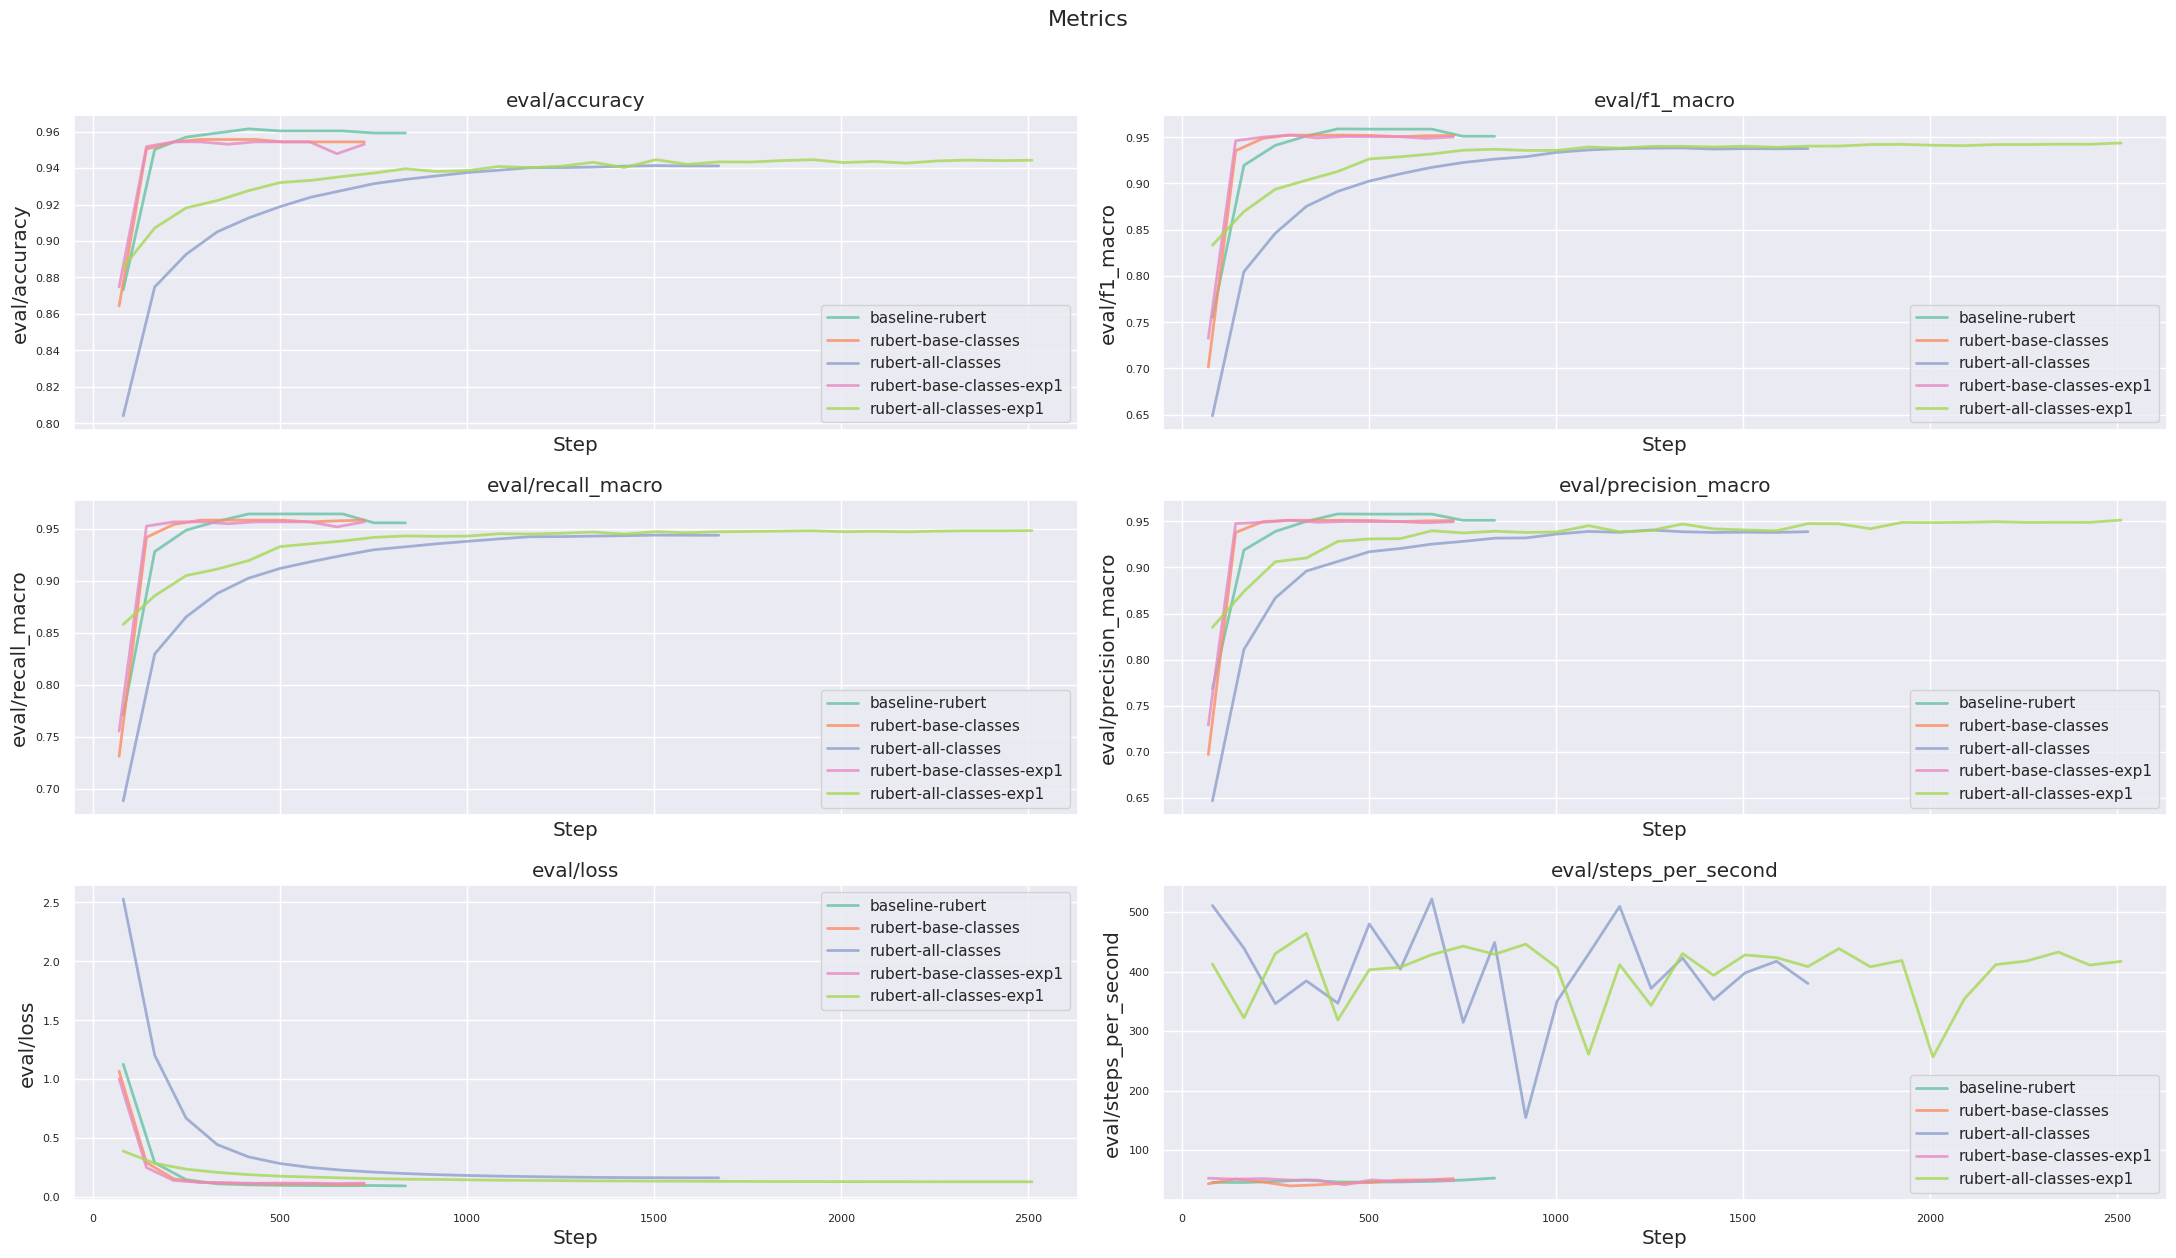

In [65]:
fig, axes = plt.subplots(3, 2, figsize=(22, 12), sharex=True)
axes = axes.flatten()

for idx, metric in enumerate(metrics):
    ax = axes[idx]
    for run_id in df["run_id"].unique():
        run_data = df[df["run_id"] == run_id]
        if metric in run_data.columns:
            ax.plot(
                run_data["_step"], 
                run_data[metric], 
                label=f"{run_data['run_name'].iloc[0]}", 
                linewidth=2, 
                alpha=0.8
            )
    
    ax.set_title(metric)
    ax.set_xlabel("Step")
    ax.set_ylabel(metric)
    ax.grid(True)
    ax.legend(fontsize=11, loc='best')
    ax.tick_params(axis='both', which='major', labelsize=8)

plt.tight_layout()
fig.suptitle("Metrics", fontsize=16, y=1.05)

plt.show()

### Выводы

Проблема подхода в том, что дообучаем мы только классификатор, и поэтому в эмбендинги скрытого слоя мы не добавляем нужную часть информации, требуемой для классификации новых классов. Поэтому усложнение классификатора (его замена на двухслойный MLP) не помогла улучшить качество.

При этом качество сильно не падает, потому что новые топики разговоров смежны с предыдущими / по крайней мере имеют такую же логику.

Если потеря оказывается значительной, то можно дообучить последние слои базовой модели вместе с классификатором.